In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "32"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"
os.environ["NUMEXPR_NUM_THREADS"] = "32"

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from utils import get_eval_stats
import scipy


In [2]:
def _baseline_legend_handle_dashed(color, linewidth):
    """Legend-only handle for baseline references: dashed line only (no dot marker)."""
    from matplotlib.lines import Line2D

    return Line2D(
        [0.0, 1.0],
        [0.0, 0.0],
        color=color,
        linestyle=(0, (5, 2.5)),
        linewidth=linewidth,
    )



def _replace_baseline_legend_handles(handles, labels, baseline_linewidth):
    """DRAKES / Pretrained: keep dashed baseline lines in legend without dot markers."""
    out_h, out_l = [], []
    colors = {"DRAKES": "#4A4E69", "Pretrained": "#9A031E"}
    for h, lab in zip(handles, labels):
        if lab in colors:
            out_h.append(_baseline_legend_handle_dashed(colors[lab], baseline_linewidth))
        else:
            out_h.append(h)
        out_l.append(lab)
    return out_h, out_l

In [3]:
target_protein=None
main_dir = "/u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/"
eval_dir = main_dir + "DRAKES/drakes_protein/fmif/eval_results/"
test_dir = eval_dir + "test/"
valid_dir = eval_dir + "validation/"
neurips_dir = eval_dir + "neurips/"
summary_func = np.mean

In [4]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

bon10_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=10.csv")
bon50_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=50.csv")

bon10_eval_stats = get_eval_stats(bon10_df, target_protein=target_protein, summary_func=summary_func)
bon50_eval_stats = get_eval_stats(bon50_df, target_protein=target_protein, summary_func=summary_func)

bon10_ddg_align = bon10_eval_stats['ddg_align']
bon50_ddg_align = bon50_eval_stats['ddg_align']

#################################

In [5]:
def calc_avg_traj(df, traj_col, target_protein=None):
    if target_protein is not None:
        df = df[df['protein_name'] == target_protein + ".pdb"]

    protein_names = sorted(set(df['protein_name']))

    cluster_means = []
    for p in protein_names:
        df_p = df[df['protein_name'] == p]
        traj_p = np.array([eval(lst) for lst in df_p[traj_col].tolist()])
        cluster_means.append(np.mean(traj_p, axis=0))

    cluster_means = np.asarray(cluster_means, dtype=float)
    avg_traj = np.mean(cluster_means, axis=0)

    # SEM of per-protein means (uncertainty of the pooled trajectory).
    if cluster_means.shape[0] <= 1:
        std_err = np.zeros_like(avg_traj)
    else:
        std_err = scipy.stats.sem(cluster_means, axis=0)

    return avg_traj, std_err


def _set_publication_style():
    plt.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 400,
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 2.5,
        "grid.alpha": 0.22,
        "grid.linestyle": "--",
        "grid.linewidth": 0.55,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "axes.titlepad": 10,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.pad": 5.0,
        "ytick.major.pad": 3.2,
    })


def _plot_trajectory_on_ax(
    ax,
    df_lst,
    names,
    traj_col,
    ylabel,
    colors=None,
    target_protein=None,
    ylim=None,
    it_space=None,
    title="Protein Evaluation Trajectory",
    show_bon=True,
    show_baselines=True,
    show_err=True,
    err_style="band",
    line_linewidth=2.45,
    baseline_linewidth=1.2,
    markersize=5.0,
    markeredgewidth=1.1,
    err_elinewidth=1.15,
    err_capsize=3.4,
):
    trajectories = []
    for df in df_lst:
        avg_traj, std_err = calc_avg_traj(df, traj_col, target_protein=target_protein)
        trajectories.append((avg_traj, std_err))

    if it_space is None:
        max_len = min([traj[0].shape[0] for traj in trajectories])
        it_space = np.arange(max_len)

    it_space = np.asarray(it_space)
    palette = colors if colors is not None else ["#3B5BDB", "#0CA678", "#E8590C", "#AE3EC9", "#C92A2A"]

    if traj_col == "spec_trajectory" and show_baselines:
        baseline_specs = [
            (drakes_ddg_align, "#4A4E69", "DRAKES"),
            (pre_ddg_align, "#9A031E", "Pretrained"),
        ]
        if show_bon:
            baseline_specs.extend([
                (bon10_ddg_align, "#E69F00", "BoN-10 Pretrained"),
                (bon50_ddg_align, "#0072B2", "BoN-50 Pretrained"),
            ])

        for y_val, color, label in baseline_specs:
            ax.axhline(
                y_val,
                color=color,
                linestyle=(0, (5, 2.5)),
                linewidth=baseline_linewidth,
                alpha=0.9,
                label=label,
                zorder=1,
            )

    all_y = []
    for i, ((traj, err), name) in enumerate(zip(trajectories, names)):
        traj, err = traj[:len(it_space)], err[:len(it_space)]
        line_color = palette[i % len(palette)]
        all_y.extend(traj.tolist())
        if show_err:
            all_y.extend((traj - err).tolist())
            all_y.extend((traj + err).tolist())

        ax.plot(
            it_space,
            traj,
            label=name,
            color=line_color,
            linewidth=line_linewidth,
            marker="o",
            markersize=markersize,
            markerfacecolor="white",
            markeredgecolor=line_color,
            markeredgewidth=markeredgewidth,
            solid_capstyle="round",
            zorder=3,
            clip_on=False,
        )
        if show_err:
            if err_style == "band":
                ax.fill_between(
                    it_space,
                    traj - err,
                    traj + err,
                    color=line_color,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2,
                )
            elif err_style == "bars":
                ax.errorbar(
                    it_space,
                    traj,
                    yerr=err,
                    fmt="none",
                    ecolor=line_color,
                    elinewidth=err_elinewidth,
                    capsize=err_capsize,
                    capthick=err_elinewidth,
                    alpha=0.88,
                    zorder=2,
                )

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.set_xlabel("Feedback Iteration", labelpad=6.5)
    ax.set_ylabel(ylabel)

    protein_info = "" if target_protein is None else f": {target_protein}"
    ax.set_title(title + protein_info, pad=8)

    ax.set_xlim(0, 5)
    ax.set_xticks(np.arange(0, 6, 1))

    if ylim is not None:
        ax.set_ylim(ylim)
    elif len(all_y) > 0:
        y_min = float(np.min(all_y))
        y_max = float(np.max(all_y))
        y_range = max(y_max - y_min, 1e-6)
        ypad = 0.08 * y_range
        ax.set_ylim(y_min - ypad, y_max + ypad)


def display_traj(
    df_lst,
    names,
    traj_col,
    ylabel,
    colors=None,
    target_protein=None,
    ylim=None,
    it_space=None,
    title="Protein Evaluation Trajectory",
    show_bon=True,
    show_baselines=True,
    show_err=True,
    err_style="band",
):
    _set_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 3.65), constrained_layout=True)
    _plot_trajectory_on_ax(
        ax, df_lst, names, traj_col, ylabel,
        colors=colors, target_protein=target_protein, ylim=ylim, it_space=it_space,
        title=title, show_bon=show_bon, show_baselines=show_baselines, show_err=show_err,
        err_style=err_style,
    )

    handles, leg_labels = ax.get_legend_handles_labels()
    handles, leg_labels = _replace_baseline_legend_handles(handles, leg_labels, 1.2)
    ncol_traj = min(4, max(2, int(np.ceil(len(handles) / 2))))
    legend = ax.legend(
        handles,
        leg_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
        ncol=ncol_traj,
        frameon=False,
        borderpad=0.48,
        handlelength=2.0,
        handletextpad=0.52,
        columnspacing=0.95,
    )

    plt.show()
    return fig, ax


def plot_four_feedback_method_trajectories(
    items,
    *,
    traj_col="spec_trajectory",
    title=(
        r"$L_{\mathrm{spec}} = 20$, $N_{\mathrm{fb}} = 5$ · 2048 masks (spectral, max-mask) · "
        r"2048 HC iters (hill-climb)"
    ),
    ylabel="Average alignment $\\Delta\\Delta G$",
    show_baselines=True,
    show_bon=True,
    show_err=False,
    err_style="band",
):
    """
    ``items``: list of ``(df, name, color)``. One curve each: pooled mean trajectory
    (same two-level averaging as ``calc_avg_traj`` across targets and sequences),
    restricted to proteins present in **every** dataframe and to the longest feedback
    prefix where **every** method has a finite pooled mean.
    """
    _set_publication_style()
    common_proteins = None
    for df, _, _ in items:
        s = set(df["protein_name"].unique())
        common_proteins = s if common_proteins is None else (common_proteins & s)
    if not common_proteins:
        raise ValueError("No overlapping protein_name across all methods in items")
    common_proteins = sorted(common_proteins)
    items_f = [
        (df[df["protein_name"].isin(common_proteins)], name, color)
        for df, name, color in items
    ]
    traj_err_nc = [(calc_avg_traj(df, traj_col), name, color) for df, name, color in items_f]
    avgs = [np.asarray(t[0][0], dtype=float) for t in traj_err_nc]
    L = int(min(a.shape[0] for a in avgs)) if avgs else 0
    if L <= 0:
        n_steps = 0
    else:
        M = np.row_stack([a[:L] for a in avgs])
        valid = np.all(np.isfinite(M), axis=0)
        if not np.any(valid):
            n_steps = 0
        else:
            bad = np.where(~valid)[0]
            n_steps = int(bad[0]) if len(bad) else L
    it_space = np.arange(n_steps)

    fig, ax = plt.subplots(figsize=(7.5, 3.65), constrained_layout=True)
    if n_steps <= 0:
        ax.text(
            0.5,
            0.5,
            "No feedback steps shared by all methods (finite pooled means).",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        plt.show()
        return fig, ax

    baseline_specs = []

    if traj_col == "spec_trajectory" and show_baselines:
        baseline_specs = [
            (drakes_ddg_align, "#4A4E69", "DRAKES"),
            (pre_ddg_align, "#9A031E", "Pretrained"),
        ]
        if show_bon:
            baseline_specs.extend([
                (bon10_ddg_align, "#E69F00", "BoN-10 Pretrained"),
                (bon50_ddg_align, "#0072B2", "BoN-50 Pretrained"),
            ])
        blw = 1.2
        for y_val, color, label in baseline_specs:
            ax.axhline(
                y_val,
                color=color,
                linestyle=(0, (5, 2.5)),
                linewidth=blw,
                alpha=0.9,
                label=label,
                zorder=1,
            )

    all_y = []
    line_linewidth, markersize, markeredgewidth = 2.45, 5.0, 1.1
    err_elinewidth, err_capsize = 1.15, 3.4
    for (avg_traj, std_err), name, color in traj_err_nc:
        traj = np.asarray(avg_traj[:n_steps])
        err = np.asarray(std_err[:n_steps])
        all_y.extend(traj.tolist())
        if show_err:
            all_y.extend((traj - err).tolist())
            all_y.extend((traj + err).tolist())
        ax.plot(
            it_space,
            traj,
            label=name,
            color=color,
            linewidth=line_linewidth,
            marker="o",
            markersize=markersize,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=markeredgewidth,
            solid_capstyle="round",
            zorder=3,
            clip_on=False,
        )
        if show_err:
            if err_style == "band":
                ax.fill_between(
                    it_space,
                    traj - err,
                    traj + err,
                    color=color,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2,
                )
            elif err_style == "bars":
                ax.errorbar(
                    it_space,
                    traj,
                    yerr=err,
                    fmt="none",
                    ecolor=color,
                    elinewidth=err_elinewidth,
                    capsize=err_capsize,
                    capthick=err_elinewidth,
                    alpha=0.88,
                    zorder=2,
                )

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)
    ax.set_xlabel("Feedback iteration", labelpad=6.5)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=8)
    if n_steps > 0:
        ax.set_xlim(0, float(it_space[-1]))
        ax.set_xticks(it_space.astype(int))

    if len(all_y) > 0:
        y_min = float(np.min(all_y))
        y_max = float(np.max(all_y))
        for y_val, *_ in baseline_specs:
            y_min = min(y_min, float(y_val))
            y_max = max(y_max, float(y_val))
        y_range = max(y_max - y_min, 1e-6)
        ypad = 0.08 * y_range
        ax.set_ylim(y_min - ypad, y_max + ypad)

    handles, leg_labels = ax.get_legend_handles_labels()
    handles, leg_labels = _replace_baseline_legend_handles(handles, leg_labels, 1.2)
    ncol = min(4, max(2, int(np.ceil(len(handles) / 2))))
    ax.legend(
        handles,
        leg_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
        ncol=ncol,
        frameon=False,
        borderpad=0.48,
        handlelength=2.0,
        handletextpad=0.52,
        columnspacing=0.95,
    )

    plt.show()
    return fig, ax



def traj_full_comp(
    dfs,
    names,
    colors,
    show_baselines=True,
    show_bon=True,
    title="ΔΔG Spectral Edit Selection Reward Trajectories",
    err_style="band",
):
    traj_col = 'spec_trajectory'
    ylabel = "Average Alignment ΔΔG"
    ylim = None
    it_space = None

    return display_traj(
        dfs,
        names,
        traj_col,
        ylabel,
        colors=colors,
        ylim=ylim,
        it_space=it_space,
        target_protein=target_protein,
        title=title,
        show_err=True,
        show_bon=show_bon,
        show_baselines=show_baselines,
        err_style=err_style,
    )


In [6]:
spec10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_rl_df = pd.read_csv(test_dir + "target/group1/" + "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_bon10_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax=True.csv")

spec20_bon10_df = pd.read_csv(neurips_dir + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=True_.csv")
# spec20_df = pd.read_csv(neurips_dir + f"remove/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=False_.csv")
spec20_rl_df = pd.read_csv(neurips_dir + f"drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv")

# spec20_df = pd.read_csv(test_dir + 'new/' + 'pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=False_.csv')
# spec20_df = pd.read_csv(neurips_dir + 'pretrained_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv')
spec20_df = pd.read_csv("/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/followups/exps4/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False__tilt_beta=1.0.csv")

spec20_2048_fb5_df = pd.read_csv(
    neurips_dir + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=2048_rmax=False_.csv"
)
# lasso20_2048_fb5_df = pd.read_csv(
#     "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results//pretrained_r6_560_TrROS_Hall_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=20_masks=2048_rmax=False_lassolambda=0.0001_tilt_beta=1.0.csv"    
# )

exclusion20_fb5_df = pd.read_csv(
    neurips_dir + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=20.csv"
)
maxmask20_2048_fb5_df = pd.read_csv(
    neurips_dir + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=20_masks=2048_rmax=False.csv"
)
hill2048_fb5_df = pd.read_csv(
    neurips_dir + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=hill-climb_maxspecorder=20_hcits=2048_rmax=False.csv"
)

spec10_eval_stats = get_eval_stats(spec10_df, target_protein=target_protein, summary_func=summary_func)
spec10_rl_eval_stats = get_eval_stats(spec10_rl_df, target_protein=target_protein, summary_func=summary_func)
spec10_bon10_eval_stats = get_eval_stats(spec10_bon10_df, target_protein=target_protein, summary_func=summary_func)

spec20_bon10_eval_stats = get_eval_stats(spec20_bon10_df, target_protein=target_protein, summary_func=summary_func)
spec20_eval_stats = get_eval_stats(spec20_df, target_protein=target_protein, summary_func=summary_func)
spec20_rl_eval_stats = get_eval_stats(spec20_rl_df, target_protein=target_protein, summary_func=summary_func)

spec20_rl_large_df = pd.read_csv(eval_dir + "drakes_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=spectral_maxspecorder=20_masks=2048_rmax=False_.csv")
spec20_rl_large_eval_stats = get_eval_stats(spec20_rl_large_df, target_protein=target_protein, summary_func=summary_func)


print(spec20_eval_stats['ddg_align'] / pre_eval_stats['ddg_align'])
print(spec20_bon10_eval_stats['ddg_align'] / bon10_eval_stats['ddg_align'])
print(spec10_rl_eval_stats['ddg_align'] / drakes_eval_stats['ddg_align'])
print(spec20_rl_large_eval_stats['ddg_align'] / drakes_eval_stats['ddg_align'])


# stat1 = get_eval_stats(lasso20_2048_fb5_df, target_protein="r6_560_TrROS_Hall", summary_func=summary_func)
# stat2 = get_eval_stats(spec20_2048_fb5_df, target_protein="r6_560_TrROS_Hall", summary_func=summary_func)
# print(stat1['ddg_align'], stat1['ddg'])
# print(stat2['ddg_align'], stat2['ddg'])

lasso20_2048_fb1_df = pd.read_csv(
    "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/tmp/pretrained_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=lasso_maxspecorder=20_masks=2048_rmax=False_lassolambda=0.0001_tilt_beta=1.0.csv"
)
spec20_2048_fb1_df = pd.read_csv(
    "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/tmp/pretrained_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=spectral_maxspecorder=20_masks=2048_rmax=False__tilt_beta=1.0.csv"
)

lasso20_bon10_df = pd.read_csv(
    "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/tmp/pretrained_r6_560_TrROS_Hall_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=20_masks=8192_rmax=False_lassolambda=0.0001_tilt_beta=1.0.csv"
)

stat_spec = get_eval_stats(spec20_bon10_df, target_protein=target_protein, summary_func=summary_func)
stat_lasso = get_eval_stats(lasso20_bon10_df, target_protein=target_protein, summary_func=summary_func)
print("Spectral",stat_spec['ddg_align'], stat_spec['ddg'])
print("Lasso", stat_lasso['ddg_align'], stat_lasso['ddg'])

print(drakes_eval_stats)
print(spec20_rl_eval_stats)

5.061218903600953
1.5516242703585426
1.185291690599282
1.1233282073874995
Spectral 0.7044259375 0.8612776933700002
Lasso 0.622153164 1.08180628
{'ddg': np.float64(0.9882918555138019), 'ddg_std': np.float64(0.8210351286830646), 'pos_ddg_prop': np.float64(0.8587239583333334), 'ddg_align': np.float64(0.6931964156210938), 'ddg_align_std': np.float64(0.09659150250666441), 'scrmsd': np.float64(1.1722478033043444), 'scrmsd_std': np.float64(1.202034489322876), 'low_scrmsd_prop': np.float64(0.9342447916666666), 'success_rate': np.float64(0.7975260416666666), 'll': np.float64(-157.515934313337), 'll_std': np.float64(41.5608073079779)}
{'ddg': np.float64(1.3795605985), 'ddg_std': np.float64(0.718970196226407), 'pos_ddg_prop': np.float64(0.9166666666666666), 'ddg_align': np.float64(0.825079859), 'ddg_align_std': np.float64(0.0460265793620099), 'scrmsd': np.float64(1.530955759435892), 'scrmsd_std': np.float64(1.8574073591198161), 'low_scrmsd_prop': np.float64(0.8583333333333333), 'success_rate': np

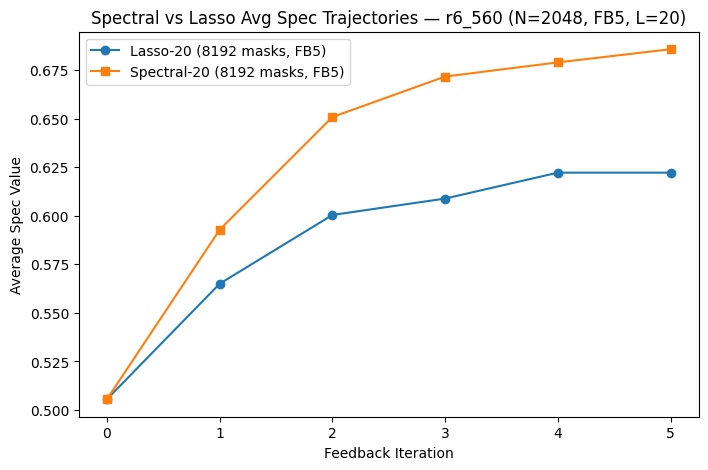

 Iteration  Spectral    Lasso
         1  0.505537 0.505537
         2  0.592785 0.564984
         3  0.650782 0.600369
         4  0.671614 0.608818
         5  0.678900 0.622153
         6  0.685677 0.622153


In [7]:
import matplotlib.pyplot as plt
import ast

def parse_trajectory(traj):
    if isinstance(traj, str):
        # Expecting a nested Python list string
        return [ast.literal_eval(row) if isinstance(row, str) else row for row in ast.literal_eval(traj)]
    elif isinstance(traj, list):
        return traj
    else:
        return []

def flatten_or_mean(trajectory):
    # Collapse each feedback iteration to a scalar (mean over any per-position values).
    means = []
    for v in trajectory:
        if isinstance(v, list):
            means.append(np.mean(v))
        else:
            means.append(v)
    return means

# Average the spec trajectory across all sequences of the target protein r6_560.
target_protein_name = "r6_560_TrROS_Hall.pdb"

def average_trajectory(df, protein_name):
    rows = df[df["protein_name"] == protein_name]
    per_row = [flatten_or_mean(parse_trajectory(s)) for s in rows["spec_trajectory"]]
    min_len = min(len(r) for r in per_row)
    per_row = [r[:min_len] for r in per_row]
    per_row = per_row[:5]
    return list(np.mean(np.stack(per_row), axis=0))

lasso_y = average_trajectory(lasso20_bon10_df, target_protein_name)
spec_y = average_trajectory(spec20_bon10_df, target_protein_name)

plt.figure(figsize=(8,5))
plt.plot(lasso_y, label="Lasso-20 (8192 masks, FB5)", marker="o")
plt.plot(spec_y, label="Spectral-20 (8192 masks, FB5)", marker="s")
plt.xlabel("Feedback Iteration")
plt.ylabel("Average Spec Value")
plt.title("Spectral vs Lasso Avg Spec Trajectories — r6_560 (N=2048, FB5, L=20)")
plt.legend()
plt.show()

# Print table (iteration, spectral, lasso)
import pandas as pd

iters = list(range(1, max(len(lasso_y), len(spec_y)) + 1))
df_table = pd.DataFrame({
    "Iteration": iters,
    "Spectral": spec_y + [None] * (len(iters) - len(spec_y)),
    "Lasso": lasso_y + [None] * (len(iters) - len(lasso_y)),
})

print(df_table.to_string(index=False))

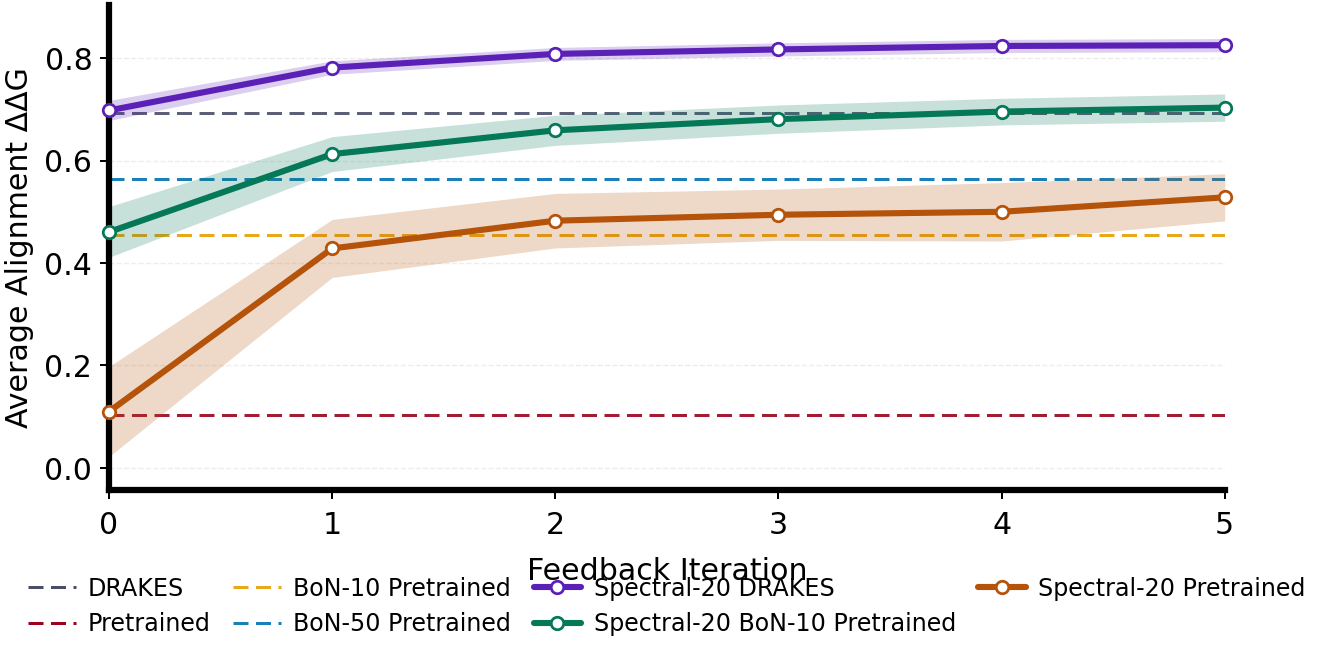

(<Figure size 1350x657 with 1 Axes>,
 <Axes: xlabel='Feedback Iteration', ylabel='Average Alignment ΔΔG'>)

In [8]:
dfs = [spec20_rl_df, spec20_bon10_df, spec20_df]#, lsq10_rl_df, lsq10_bon10_df, lsq10_df, ex10_df]
names = ['Spectral-20 DRAKES',  'Spectral-20 BoN-10 Pretrained', 'Spectral-20 Pretrained']#, 'Linear-10 DRAKES', 'Linear-10 BoN-10', 'Linear-10', 'Exclusion-10']
colors = ["#5B21B6", "#047857", "#B45309", "#D68BF2", "#E655C1", "#BF5F87", "green"]  # spectral traj lines (distinct from grey/red baselines)

traj_full_comp(dfs, names, colors, title='')

/tmp/ipykernel_1389520/3039550088.py:265: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  M = np.row_stack([a[:L] for a in avgs])


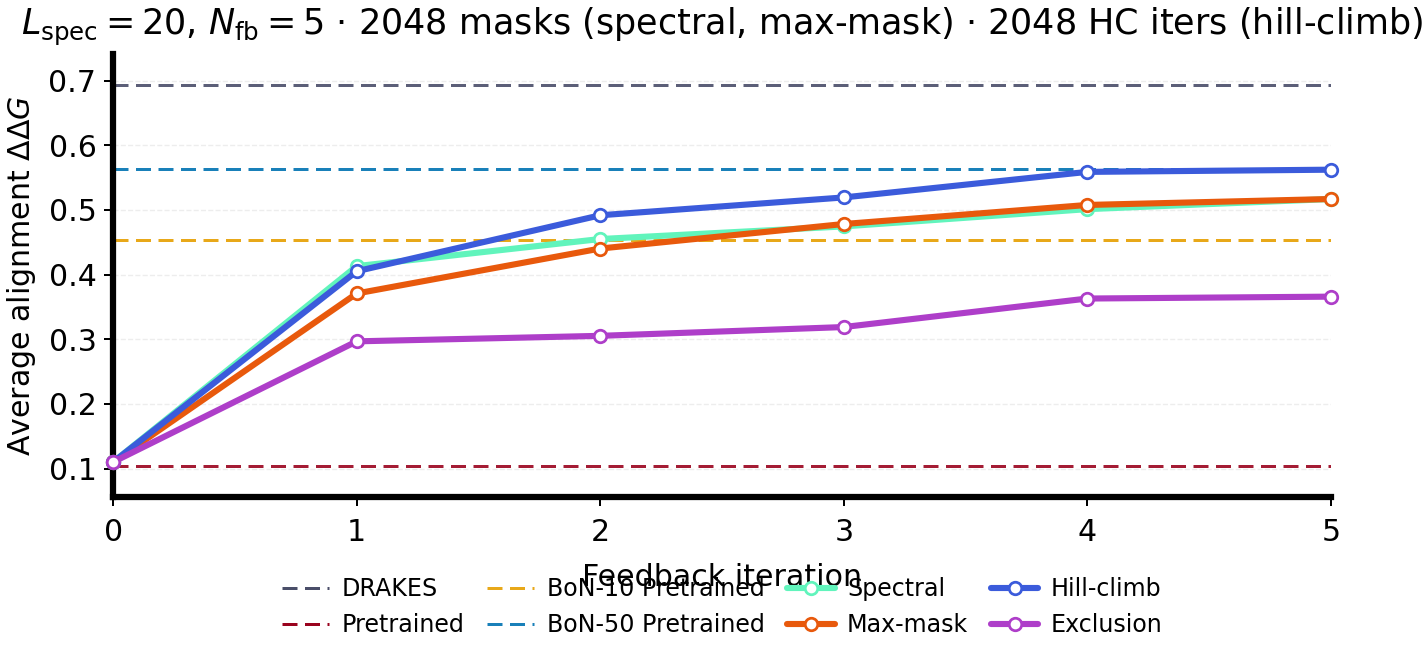

In [9]:
# Four pooled trajectories only: spectral vs max-mask vs hill-climb vs exclusion (same L_spec=20, N_fb=5, 2048 budget).
four_way_traj_specs_2048 = [
    (spec20_2048_fb5_df, "Spectral", "#61F4BC"),
    (maxmask20_2048_fb5_df, "Max-mask", "#E8590C"),
    (hill2048_fb5_df, "Hill-climb", "#3B5BDB"),
    (exclusion20_fb5_df, "Exclusion", "#AE3EC9"),
]
_ = plot_four_feedback_method_trajectories(four_way_traj_specs_2048)


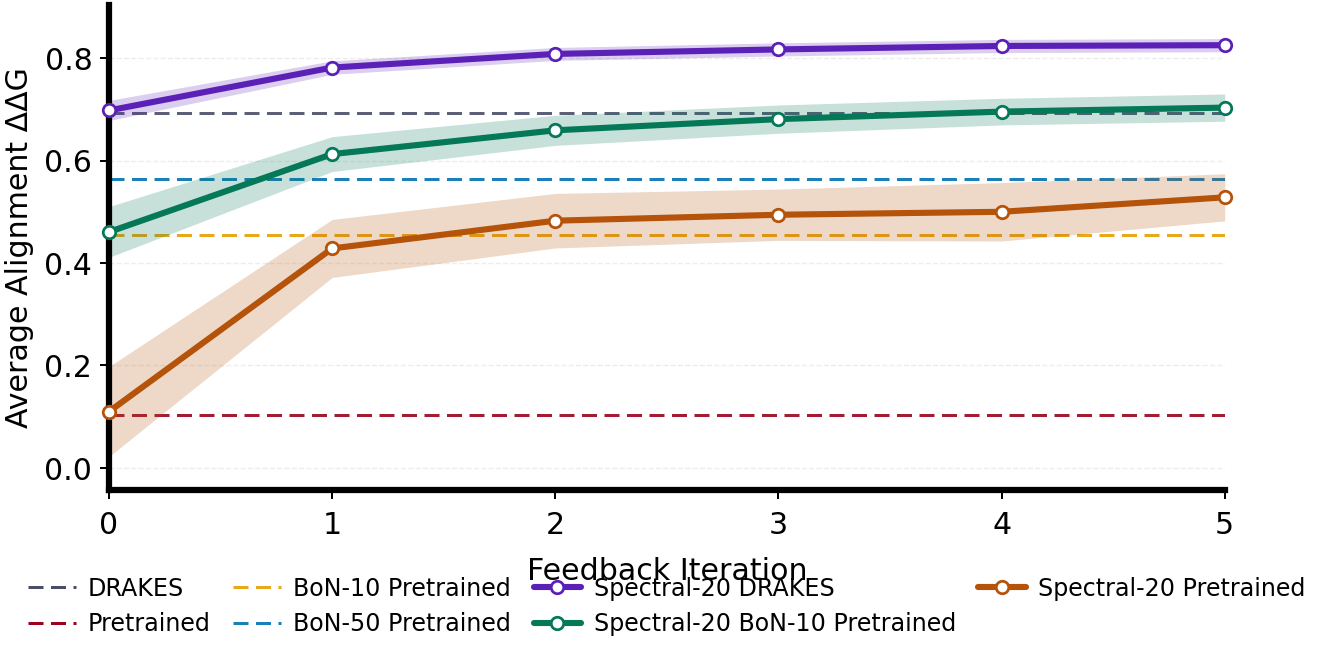

Saved PDF to: neurips_figures/traj_full_comp_neurips2026.pdf


In [10]:
pdf_path = "neurips_figures/traj_full_comp_neurips2026.pdf"

fig, _ = traj_full_comp(dfs, names, colors, title='')
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"Saved PDF to: {pdf_path}")

In [11]:
def _find_matching_protein_name(aliases, df):
    """Return a protein_name value in ``df`` matching any string in ``aliases``."""
    names = df["protein_name"].astype(str).unique()
    for a in aliases:
        a = str(a).replace(".pdb", "")
        for n in names:
            n0 = n.replace(".pdb", "")
            if n0 == a or a in n0 or (len(a) >= 3 and n0 in a):
                return n
    return None


def _plot_scatter_corr_on_ax(
    ax,
    df_list,
    labels,
    protein,
    *,
    selected_samples=None,
    colors=None,
    ddg_label='ddg_eval',
    ylabel='loglikelihood',
    yname='Log Likelihood',
    xname=None,
    negate_x=False,
    axis_clip_quantiles=None,
    rng_seed=42,
    scatter_marker_size=34,
    scatter_edgewidth=0.55,
    plot_mode="scatter",
    faint_point_alpha=0.09,
    faint_point_ms=42,
    contour_alpha=0.36,
    kde_max_points=4500,
    n_contour_levels=3,
    add_outer_envelope_contour=False,
    highlight_protein_specs=None,
    highlight_series_indices=None,
    outlier_protein_scatter_only=False,
    outlier_quantiles=(0.01, 0.99),
    density_draw_faint_points=True,
    density_draw_highlights=True,
):
    if colors is None:
        colors = ["#3B5BDB", "#0CA678", "#E8590C", "#AE3EC9", "#C92A2A"]

    rng = np.random.default_rng(rng_seed)

    def _axis_labels():
        if xname is not None:
            ax.set_xlabel(xname, labelpad=6.5)
        elif str(ddg_label).lower() in {"scrmsd", "sc_rmsd"}:
            ax.set_xlabel('scRMSD', labelpad=6.5)
        elif ddg_label == 'ddg_eval':
            ax.set_xlabel('Evaluation ΔΔG', labelpad=6.5)
        else:
            ax.set_xlabel('Alignment ΔΔG', labelpad=6.5)
        ax.set_ylabel(yname)

    def _extract_xy(df_use):
        x = pd.to_numeric(df_use[ddg_label], errors='coerce').to_numpy()
        y = pd.to_numeric(df_use[ylabel], errors='coerce').to_numpy()
        if negate_x:
            x = -x
        valid = np.isfinite(x) & np.isfinite(y)
        return x[valid], y[valid]

    if plot_mode == "scatter":
        for i, df in enumerate(df_list):
            df_use = df
            if protein is not None:
                df_use = df_use[df_use['protein_name'] == protein + ".pdb"]

            x, y = _extract_xy(df_use)

            if selected_samples is not None and len(x) > selected_samples:
                ids = rng.choice(len(x), size=selected_samples, replace=False)
                x = x[ids]
                y = y[ids]

            ax.scatter(
                x,
                y,
                label=labels[i],
                color=colors[i % len(colors)],
                s=scatter_marker_size,
                alpha=0.72,
                edgecolors='white',
                linewidths=scatter_edgewidth,
                zorder=3,
            )
        _axis_labels()
        return

    if plot_mode != "density":
        raise ValueError("plot_mode must be 'scatter' or 'density'")

    from scipy.stats import gaussian_kde
    from matplotlib.colors import LinearSegmentedColormap

    if highlight_protein_specs is None:
        highlight_protein_specs = (
            (("r6_560_TrROS_Hall", "r6_TrROS_Hall", "r6"), "*", "* R6-560"),
            (("v2K43S_2KVV",), "s", "[] 2KVV"),
        )

    hs_idx = highlight_series_indices
    if hs_idx is not None:
        hs_idx = frozenset(int(j) for j in hs_idx)

    lim_x_chunks, lim_y_chunks = [], []
    protein_centroids = []

    for i, df in enumerate(df_list):
        df_use = df
        if protein is not None:
            df_use = df_use[df_use['protein_name'] == protein + ".pdb"]

        x, y = _extract_xy(df_use)
        lim_x_chunks.append(x)
        lim_y_chunks.append(y)

        # Cache per-protein centroids for optional outlier markers (normally off for publication panels).
        if outlier_protein_scatter_only and "protein_name" in df_use.columns:
            x_raw = pd.to_numeric(df_use[ddg_label], errors='coerce').to_numpy()
            y_raw = pd.to_numeric(df_use[ylabel], errors='coerce').to_numpy()
            if negate_x:
                x_raw = -x_raw
            names_raw = df_use["protein_name"].astype(str).to_numpy()
            valid_raw = np.isfinite(x_raw) & np.isfinite(y_raw)
            if np.any(valid_raw):
                prot_df = pd.DataFrame({
                    "protein_name": names_raw[valid_raw],
                    "x": x_raw[valid_raw],
                    "y": y_raw[valid_raw],
                })
                for row in prot_df.groupby("protein_name", as_index=False)[["x", "y"]].mean().itertuples(index=False):
                    protein_centroids.append((i, float(row.x), float(row.y)))

        col = colors[i % len(colors)]

        x_k, y_k = x, y
        if len(x_k) > kde_max_points:
            pick = rng.choice(len(x_k), kde_max_points, replace=False)
            x_k, y_k = x_k[pick], y_k[pick]

        try:
            if len(x_k) >= 5:
                kde = gaussian_kde(np.vstack([x_k, y_k]))
                x_min, x_max = float(np.min(x)), float(np.max(x))
                y_min, y_max = float(np.min(y)), float(np.max(y))
                if str(ylabel).lower() == "scrmsd":
                    y_max = max(y_max, 10.0)
                xr = max(x_max - x_min, 1e-6)
                yr = max(y_max - y_min, 1e-6)
                pad_x, pad_y = 0.08 * xr, 0.08 * yr
                gx = np.linspace(x_min - pad_x, x_max + pad_x, 96)
                gy = np.linspace(y_min - pad_y, y_max + pad_y, 96)
                Xi, Yi = np.meshgrid(gx, gy)
                zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
                z_max = float(np.nanmax(zi))
                if z_max > 0 and np.isfinite(z_max):
                    z_low = z_max * 0.08
                    lev = np.linspace(z_low, z_max, n_contour_levels + 1)
                    cmap = LinearSegmentedColormap.from_list(
                        f"kde_{i}", ["white", col], N=256
                    )
                    ax.contourf(
                        Xi,
                        Yi,
                        zi,
                        levels=lev,
                        cmap=cmap,
                        alpha=contour_alpha,
                        antialiased=True,
                        zorder=1 + i * 0.02,
                    )
                    ax.contour(
                        Xi,
                        Yi,
                        zi,
                        levels=lev,
                        colors=[col],
                        alpha=min(0.95, contour_alpha + 0.50),
                        linewidths=1.55,
                        zorder=1.25 + i * 0.02,
                    )

                    # One extra outer contour that envelopes the algorithm's point cloud.
                    if add_outer_envelope_contour:
                        try:
                            z_data = kde(np.vstack([x_k, y_k]))
                            z_env = max(float(np.nanmin(z_data)) * 1.0, z_max * 1e-6)
                            ax.contour(
                                Xi,
                                Yi,
                                zi,
                                levels=[z_env],
                                colors=[col],
                                alpha=min(0.78, contour_alpha + 0.28),
                                linewidths=1.7,
                                zorder=1.5 + i * 0.02,
                            )
                        except Exception:
                            pass
        except np.linalg.LinAlgError:
            pass

        if density_draw_faint_points:
            x_draw, y_draw = x, y
            if selected_samples is not None and len(x) > selected_samples:
                ids = rng.choice(len(x), size=selected_samples, replace=False)
                x_draw, y_draw = x[ids], y[ids]
            elif len(x) > 14000:
                ids = rng.choice(len(x), 14000, replace=False)
                x_draw, y_draw = x[ids], y[ids]

            ax.scatter(
                x_draw,
                y_draw,
                color=col,
                s=faint_point_ms,
                alpha=faint_point_alpha,
                edgecolors="none",
                linewidths=0,
                zorder=4,
                rasterized=True,
            )

            ax.plot(
                [],
                [],
                "o",
                color=col,
                label=labels[i],
                markersize=10.5,
                markeredgecolor="white",
                markeredgewidth=0.85,
                linestyle="None",
            )

    if density_draw_highlights:
        hi_ms = max(14.0, float(scatter_marker_size) * 0.72)
        hi_mew = float(scatter_edgewidth) * 1.35
        hi_symbol_size = scatter_marker_size * 3.9

        for aliases, mkr, _leg in highlight_protein_specs:
            for i, df in enumerate(df_list):
                if hs_idx is not None and i not in hs_idx:
                    continue
                df_use = df
                if protein is not None:
                    df_use = df_use[df_use['protein_name'] == protein + ".pdb"]
                pdbn = _find_matching_protein_name(aliases, df_use)
                if pdbn is None:
                    continue
                sub = df_use[df_use["protein_name"] == pdbn]
                xe, ye = _extract_xy(sub)
                if xe.size == 0:
                    continue
                mx, my = float(np.mean(xe)), float(np.mean(ye))
                lim_x_chunks.append(np.array([mx]))
                lim_y_chunks.append(np.array([my]))
                col = colors[i % len(colors)]
                # Keep all stars at one larger fixed size; squares remain smaller.
                s_draw = hi_symbol_size * (2.35 if mkr == "*" else 0.80)
                ax.scatter(
                    mx,
                    my,
                    marker=mkr,
                    s=s_draw,
                    facecolors=col,
                    edgecolors="white",
                    linewidths=hi_mew,
                    zorder=8,
                )

    if lim_x_chunks:
        xc = np.concatenate(lim_x_chunks)
        yc = np.concatenate(lim_y_chunks)
        xc = xc[np.isfinite(xc)]
        yc = yc[np.isfinite(yc)]
        if xc.size and yc.size:
            if axis_clip_quantiles is not None:
                q_low, q_high = axis_clip_quantiles
                q_low = float(np.clip(q_low, 0.0, 1.0))
                q_high = float(np.clip(q_high, 0.0, 1.0))
                if q_low < q_high:
                    x0, x1 = np.quantile(xc, [q_low, q_high])
                    y0, y1 = np.quantile(yc, [q_low, q_high])
                else:
                    x0, x1 = float(np.min(xc)), float(np.max(xc))
                    y0, y1 = float(np.min(yc)), float(np.max(yc))
            else:
                x0, x1 = float(np.min(xc)), float(np.max(xc))
                y0, y1 = float(np.min(yc)), float(np.max(yc))

            xr = max(float(x1) - float(x0), 0.02)
            yr = max(float(y1) - float(y0), 0.02)
            ax.set_xlim(float(x0) - 0.03 * xr, float(x1) + 0.03 * xr)
            ax.set_ylim(float(y0) - 0.03 * yr, float(y1) + 0.03 * yr)

            if density_draw_highlights and outlier_protein_scatter_only and protein_centroids:
                oq_low, oq_high = outlier_quantiles
                oq_low = float(np.clip(oq_low, 0.0, 1.0))
                oq_high = float(np.clip(oq_high, 0.0, 1.0))
                if oq_low < oq_high:
                    ox0, ox1 = np.quantile(xc, [oq_low, oq_high])
                    oy0, oy1 = np.quantile(yc, [oq_low, oq_high])
                else:
                    ox0, ox1, oy0, oy1 = x0, x1, y0, y1

                for ds_idx, mx, my in protein_centroids:
                    if (mx < ox0) or (mx > ox1) or (my < oy0) or (my > oy1):
                        col = colors[ds_idx % len(colors)]
                        ax.scatter(
                            mx,
                            my,
                            marker="o",
                            s=hi_symbol_size * 0.95,
                            facecolors=col,
                            edgecolors="white",
                            linewidths=hi_mew,
                            zorder=8,
                        )

    _axis_labels()


def evaluate_ddg_ll_corr_mult(
    df_list,
    labels,
    protein,
    title='',
    selected_samples=None,
    colors=None,
    ddg_label='ddg_eval',
    ylabel='loglikelihood',
    yname='Log Likelihood',
    xname=None,
    negate_x=False,
    axis_clip_quantiles=None,
    save_pdf_path=None,
):
    """NeurIPS-ready multi-dataset scatter for ΔΔG vs target metric."""
    _set_publication_style()

    fig, ax = plt.subplots(figsize=(7.4, 4.15), constrained_layout=True)
    _plot_scatter_corr_on_ax(
        ax, df_list, labels, protein,
        selected_samples=selected_samples, colors=colors,
        ddg_label=ddg_label, ylabel=ylabel, yname=yname,
        xname=xname, negate_x=negate_x, axis_clip_quantiles=axis_clip_quantiles,
    )

    if title:
        ax.set_title(title, pad=8)

    ax.grid(True, axis='both', alpha=0.35, linestyle="--", linewidth=0.55)
    ax.set_axisbelow(True)

    handles, leg_labels = ax.get_legend_handles_labels()
    ncol_corr = min(3, max(1, len(handles)))
    legend = ax.legend(
        handles,
        leg_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=ncol_corr,
        frameon=False,
        borderpad=0.48,
        handlelength=2.0,
        handletextpad=0.55,
        columnspacing=1.0,
    )

    if save_pdf_path:
        import os
        directory = os.path.dirname(save_pdf_path)
        if directory:
            os.makedirs(directory, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight")
        print(f"Saved PDF to: {save_pdf_path}")

    plt.show()
    return fig, ax


def _expand_scatter_limits_from_collections(ax, pad_frac=0.10, pad_min=0.02):
    """Pad x/y limits to the point cloud so it does not sit in a tight corner of the axes."""
    xs, ys = [], []
    for coll in ax.collections:
        off = coll.get_offsets()
        if off is None or len(off) == 0:
            continue
        xs.append(off[:, 0])
        ys.append(off[:, 1])
    if not xs:
        return
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return
    x0, x1 = float(np.min(x)), float(np.max(x))
    y0, y1 = float(np.min(y)), float(np.max(y))
    xr = max(x1 - x0, pad_min)
    yr = max(y1 - y0, pad_min)
    ax.set_xlim(x0 - pad_frac * xr, x1 + pad_frac * xr)
    ax.set_ylim(y0 - pad_frac * yr, y1 + pad_frac * yr)


def _dedupe_legend_handles_labels(handles, labels):
    seen = set()
    out_h, out_l = [], []
    for h, lab in zip(handles, labels):
        if lab not in seen:
            seen.add(lab)
            out_h.append(h)
            out_l.append(lab)
    return out_h, out_l


def _crop_structure_image_tight(
    im,
    black_thresh=0.08,
    edge_shrink=0.92,
    padding_frac=0.08,
    square_output=True,
):
    """Crop near-black borders, add black padding, then (optionally) a square letterbox.

    black_thresh: mean RGB below this (0–1) counts as background for the tight bbox.
    padding_frac: uniform black border after that bbox, as a fraction of max(crop H, crop W).
        Larger = more black margin around the protein.
    square_output: if True, pad to a centered square (black on the shorter side).
    edge_shrink: after framing, keep only the central fraction (1.0 = no extra zoom-in).
    """
    im = np.asarray(im)
    if im.size == 0:
        return im
    if im.ndim == 2:
        gray = im.astype(np.float64)
        if gray.max() > 1.0:
            gray /= 255.0
    elif im.ndim == 3 and im.shape[-1] >= 3:
        rgb = im[..., :3].astype(np.float64)
        if rgb.max() > 1.0:
            rgb /= 255.0
        gray = np.mean(rgb, axis=-1)
    else:
        return im
    mask = gray > black_thresh
    if not np.any(mask):
        return im
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    r0, r1 = int(np.argmax(rows)), int(len(rows) - np.argmax(rows[::-1]))
    c0, c1 = int(np.argmax(cols)), int(len(cols) - np.argmax(cols[::-1]))
    im = im[r0:r1, c0:c1]
    if im.size == 0:
        return im
    fill = 0.0 if im.dtype.kind == "f" else 0
    h, w = int(im.shape[0]), int(im.shape[1])
    pad = max(2, int(round(max(h, w) * float(padding_frac))))
    if im.ndim == 2:
        im = np.pad(im, ((pad, pad), (pad, pad)), mode="constant", constant_values=fill)
    else:
        im = np.pad(im, ((pad, pad), (pad, pad), (0, 0)), mode="constant", constant_values=fill)
    if square_output:
        h, w = int(im.shape[0]), int(im.shape[1])
        side = max(h, w)
        pt = (side - h) // 2
        pb = side - h - pt
        pl = (side - w) // 2
        pr = side - w - pl
        if im.ndim == 2:
            im = np.pad(im, ((pt, pb), (pl, pr)), mode="constant", constant_values=fill)
        else:
            im = np.pad(im, ((pt, pb), (pl, pr), (0, 0)), mode="constant", constant_values=fill)
    if edge_shrink < 1.0 and im.size > 0:
        h, w = im.shape[0], im.shape[1]
        dh, dw = int(h * (1.0 - edge_shrink) / 2), int(w * (1.0 - edge_shrink) / 2)
        im = im[dh : h - dh, dw : w - dw]
    return im



def _apply_neurips_reference_axis_style(ax):
    """Serif-style reference: black frame, inward ticks, major+minor dashed grid."""
    from matplotlib.ticker import AutoMinorLocator

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(
        True,
        which="major",
        axis="both",
        linestyle="--",
        linewidth=0.78,
        alpha=0.52,
        color="#9a9a9a",
        zorder=0,
    )
    ax.grid(
        True,
        which="minor",
        axis="both",
        linestyle=":",
        linewidth=0.58,
        alpha=0.38,
        color="#bcbcbc",
        zorder=0,
    )
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)
    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=5.6,
        width=1.18,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=3.3,
        width=0.9,
    )


def traj_and_scatter_unified_panel(
    dfs,
    line_names,
    line_colors,
    scatter_df_list,
    scatter_labels,
    scatter_colors,
    *,
    target_protein=None,
    line_title="ΔΔG Spectral Edit Selection Reward Trajectories",
    scatter_title="",
    show_baselines=True,
    show_bon=True,
    err_style="band",
    scatter_ddg_label='ddg',
    scatter_y='scrmsd',
    scatter_yname='scRMSD',
    scatter_xname=None,
    scatter_negate_x=False,
    scatter_axis_clip_quantiles=None,
    scatter_outlier_protein_scatter_only=False,
    scatter_outlier_quantiles=(0.01, 0.99),
    scatter_selected_samples=None,
    scatter_plot_mode="density",
    scatter_highlight_protein_specs=None,
    scatter_highlight_series_indices=None,
    scatter_region_legend=True,
    save_pdf_path=None,
    structure_image_paths=None,
    structure_image_captions=None,
    structure_caption_color=None,
    structure_crop_black_thresh=0.01,
    structure_crop_edge_shrink=1.0,
    structure_crop_padding_frac=0.10,
    structure_crop_square=True,
):
    """Trajectory + scatter with optional structure column; one merged legend centered above all panels.

    Crop tuning (structure images): ``structure_crop_black_thresh``, ``structure_crop_edge_shrink``,
    ``structure_crop_padding_frac`` (more black margin), ``structure_crop_square``; see
    ``_crop_structure_image_tight``.
    """
    import os

    _set_publication_style()

    _default_structure_paths = (
        main_dir + "neurips_fig5_pdfs/pretrained_r6_650_TrROS_Hall_esmfold_pymol.png",
        main_dir + "neurips_fig5_pdfs/pretrained_v2K43S_2KVV_esmfold_pymol.png",
    )
    _default_structure_captions = ("R6 TrROS Hall", "2KVV")
    if structure_image_paths is None:
        structure_image_paths = _default_structure_paths
    if structure_image_captions is None:
        structure_image_captions = _default_structure_captions

    _unified_panel_rc = {
        "font.family": "DejaVu Sans",
        "font.sans-serif": [
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "Liberation Sans",
        ],
        "mathtext.fontset": "dejavusans",
        "font.size": 16.25,
        "axes.titlesize": 19.5,
        "axes.labelsize": 26.0,
        "xtick.labelsize": 18.5,
        "ytick.labelsize": 18.5,
        "legend.fontsize": 20.0,
        "axes.edgecolor": "black",
        "axes.linewidth": 5.5,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "xtick.major.width": 1.12,
        "ytick.major.width": 1.12,
        "xtick.minor.width": 0.86,
        "ytick.minor.width": 0.86,
        "xtick.color": "black",
        "ytick.color": "black",
        "legend.handlelength": 2.95,
        "legend.handletextpad": 0.82,
        "legend.borderpad": 0.65,
        "legend.labelspacing": 0.82,
        "legend.columnspacing": 1.38,
    }

    with plt.rc_context(_unified_panel_rc):
        fig = plt.figure(figsize=(21.2, 7.05))
        paths = list(structure_image_paths) if structure_image_paths else []
        caps = list(structure_image_captions) if structure_image_captions else []
        n_examples = max(len(paths), len(caps), 1)
        n_cols_img = 1 if n_examples <= 2 else (3 if n_examples >= 6 else min(3, n_examples))
        n_rows_img = int(np.ceil(n_examples / n_cols_img))

        gs_main = fig.add_gridspec(
            1,
            4,
            width_ratios=[1.0, 0.22, 1.0, 0.5],
            wspace=0.009,
            left=0.055,
            right=0.985,
            top=0.86,
            bottom=0.13,
        )
        ax_line = fig.add_subplot(gs_main[0, 0])
        ax_scat = fig.add_subplot(gs_main[0, 2])
        gs_img = gs_main[0, 3].subgridspec(n_rows_img, n_cols_img, hspace=0.20, wspace=0.07)
        img_axes = [fig.add_subplot(gs_img[r, c]) for r in range(n_rows_img) for c in range(n_cols_img)]
        for _axi in img_axes:
            _axi.axis("off")

        _plot_trajectory_on_ax(
            ax_line,
            dfs,
            line_names,
            "spec_trajectory",
            "Average Alignment ΔΔG",
            colors=line_colors,
            ylim=None,
            it_space=None,
            target_protein=target_protein,
            title=line_title,
            show_bon=show_bon,
            show_baselines=show_baselines,
            show_err=True,
            err_style=err_style,
            line_linewidth=7.25,
            baseline_linewidth=2.55,
            markersize=8.75,
            markeredgewidth=2.35,
            err_elinewidth=1.85,
        )

        # if scatter_plot_mode == "bar":
        #     # Bar panel adapted from analyze_new_spectral.ipynb (Sec. 5.3 table values).
        #     methods = ["Pretrained", "BoN-10", "DRAKES"]
        #     ddg_before = np.array([36.1, 59.4, 85.9])
        #     ddg_after = np.array([66.7, 84.2, 94.4])
        #     success_before = np.array([33.9, 56.1, 79.8])
        #     success_after = np.array([62.5, 80.8, 80.0])
        #     before_color = "#D79264"
        #     after_color = "#44A2A6"
        #     delta_green = "#2E9E5B"

        #     # Replace single scatter axis with two stacked bar axes in the same panel slot.
        #     ax_scat.remove()
        #     gs_bar = gs_main[0, 2].subgridspec(2, 1, hspace=0.26)
        #     # Two independent stacked bar subfigures (no shared axis object).
        #     ax_bar_top = fig.add_subplot(gs_bar[0, 0])
        #     ax_bar_bot = fig.add_subplot(gs_bar[1, 0])
        #     ax_scat = ax_bar_top
        #     bar_axes = (ax_bar_top, ax_bar_bot)

        #     # Numeric x positions so requested xlim(25, 105) still shows bars.
        #     x = np.array([40.0, 65.0, 90.0])
        #     width = 7.8

        #     ddg_ymin, ddg_ymax = 25, 105
        #     ax_bar_top.bar(
        #         x - width / 2,
        #         ddg_before - ddg_ymin,
        #         width,
        #         bottom=ddg_ymin,
        #         color=before_color,
        #         edgecolor="black",
        #         linewidth=2.1,
        #         label="Baseline",
        #     )
        #     ax_bar_top.bar(
        #         x + width / 2,
        #         ddg_after - ddg_ymin,
        #         width,
        #         bottom=ddg_ymin,
        #         color=after_color,
        #         edgecolor="black",
        #         linewidth=2.1,
        #         label="Spectral Feedback",
        #     )
        #     ax_bar_top.set_ylabel("Eval ΔΔG\n> 0 (%)", fontsize=18, labelpad=6)
        #     ax_bar_top.set_ylim(ddg_ymin, ddg_ymax)
        #     ax_bar_top.set_xlim(25, 105)
        #     ax_bar_top.set_yticks([50, 100])
        #     ax_bar_top.set_yticklabels(["50%", "100%"])
        #     ax_bar_top.set_xticks(x)
        #     ax_bar_top.set_xticklabels(methods, rotation=0, fontsize=26, ha="center")
        #     ax_bar_top.tick_params(axis="x", pad=6)
        #     ax_bar_top.tick_params(axis="y", labelsize=19)

        #     for i, (before, after) in enumerate(zip(ddg_before, ddg_after)):
        #         ax_bar_top.text(
        #             x[i] + width / 2,
        #             after + 2.0,
        #             f"+{after - before:.1f}%",
        #             ha="center",
        #             va="bottom",
        #             fontsize=25,
        #             color=delta_green,
        #         )

        #     succ_ymin, succ_ymax = 25, 105
        #     ax_bar_bot.bar(
        #         x - width / 2,
        #         success_before - succ_ymin,
        #         width,
        #         bottom=succ_ymin,
        #         color=before_color,
        #         edgecolor="black",
        #         linewidth=2.1,
        #     )
        #     ax_bar_bot.bar(
        #         x + width / 2,
        #         success_after - succ_ymin,
        #         width,
        #         bottom=succ_ymin,
        #         color=after_color,
        #         edgecolor="black",
        #         linewidth=2.1,
        #     )
        #     ax_bar_bot.set_ylabel("Success Rate\n(%)", fontsize=18, labelpad=6)
        #     ax_bar_bot.set_ylim(succ_ymin, succ_ymax)
        #     ax_bar_bot.set_xlim(25, 105)
        #     ax_bar_bot.set_yticks([25, 75])
        #     ax_bar_bot.set_yticklabels(["25%", "75%"])
        #     ax_bar_bot.set_xticks(x)
        #     ax_bar_bot.set_xticklabels(methods, rotation=0, fontsize=26, ha="center")
        #     ax_bar_bot.tick_params(axis="x", pad=6)
        #     ax_bar_bot.tick_params(axis="y", labelsize=19)

        #     for i, (before, after) in enumerate(zip(success_before, success_after)):
        #         ax_bar_bot.text(
        #             x[i] + width / 2,
        #             after + 2.0,
        #             f"+{after - before:.1f}%",
        #             ha="center",
        #             va="bottom",
        #             fontsize=25,
        #             color=delta_green,
        #         )

        #     # Keep Baseline/Spectral Feedback legend inside bar panel.
        #     ax_bar_top.legend(
        #         loc="upper left",
        #         frameon=False,
        #         fontsize=16.5,
        #         handlelength=1.7,
        #         handletextpad=0.55,
        #         borderpad=0.2,
        #         labelspacing=0.3,
        #     )
        if scatter_plot_mode == "bar":
            # Exact bar style/values from analyze_new_spectral.ipynb final figure.
            methods = ["Pretrained", "BoN-10", "DRAKES"]
            ddg_before = np.array([36.1, 59.4, 85.9])
            ddg_after = np.array([66.7, 84.2, 94.4])
            success_before = np.array([33.9, 56.1, 79.8])
            success_after = np.array([62.5, 80.8, 80.0])

            before_color = "#D79264"
            after_color = "#44A2A6"
            delta_green = "#2E9E5B"

            x = np.arange(len(methods))
            width = 0.34

            # Replace contour axis with stacked bar axes in the same panel slot.
            ax_scat.remove()
            gs_bar = gs_main[0, 2].subgridspec(2, 1, hspace=0.02)
            ax_bar_top = fig.add_subplot(gs_bar[0, 0])
            ax_bar_bot = fig.add_subplot(gs_bar[1, 0], sharex=ax_bar_top)
            ax_scat = ax_bar_top
            bar_axes = (ax_bar_top, ax_bar_bot)

            delta_green = "#1F8A4C"
            delta_fontsize = 22
            delta_pad = 3.0
            yticks_pct = [0, 25, 50, 75, 100]
            ytick_labels = [f"{v}%" for v in yticks_pct]

            ax_bar_top.bar(x - width / 2, ddg_before, width, color=before_color, edgecolor="black", linewidth=3.0, label="Baseline", zorder=3)
            ax_bar_top.bar(x + width / 2, ddg_after,  width, color=after_color,  edgecolor="black", linewidth=3.0, label="Spectral Feedback", zorder=3)
            ax_bar_top.set_ylabel("Eval ΔΔG > 0", labelpad=8)
            ax_bar_top.set_ylim(0, 105)
            ax_bar_top.set_yticks(yticks_pct)
            ax_bar_top.set_yticklabels(ytick_labels)
            ax_bar_top.tick_params(axis="x", labelbottom=False)
            ax_bar_top.legend(
                loc="upper left",
                frameon=False,
                fontsize=20,
                handlelength=1.9,
                handletextpad=0.9,
                borderpad=0.25,
                labelspacing=0.55,
            )

            for i, (before, after) in enumerate(zip(ddg_before, ddg_after)):
                ax_bar_top.text(
                    x[i] + width / 2,
                    after + delta_pad,
                    f"+{after - before:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=delta_fontsize,
                    fontweight="bold",
                    color=delta_green,
                    zorder=5,
                )

            ax_bar_bot.bar(x - width / 2, success_before, width, color=before_color, edgecolor="black", linewidth=3.0, zorder=3)
            ax_bar_bot.bar(x + width / 2, success_after,  width, color=after_color,  edgecolor="black", linewidth=3.0, zorder=3)
            ax_bar_bot.set_ylabel("Success Rate", labelpad=8)
            ax_bar_bot.set_ylim(0, 105)
            ax_bar_bot.set_yticks(yticks_pct)
            ax_bar_bot.set_yticklabels(ytick_labels)
            ax_bar_bot.set_xticks(x)
            ax_bar_bot.set_xticklabels(methods, fontsize=22)

            for i, (before, after) in enumerate(zip(success_before, success_after)):
                ax_bar_bot.text(
                    x[i] + width / 2,
                    after + delta_pad,
                    f"+{after - before:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=delta_fontsize,
                    fontweight="bold",
                    color=delta_green,
                    zorder=5,
                )

            for _bax in bar_axes:
                _bax.set_axisbelow(True)
                _bax.yaxis.grid(True, color="#B8B8B8", linewidth=0.9, alpha=0.55, zorder=0)
                _bax.xaxis.grid(False)
                _bax.spines["top"].set_visible(False)
                _bax.spines["right"].set_visible(False)
                for _spine in (_bax.spines["left"], _bax.spines["bottom"]):
                    _spine.set_linewidth(3.0)
                    _spine.set_capstyle("butt")
                    _spine.set_joinstyle("miter")
                _bax.tick_params(axis="both", width=2.4, length=7)
                _bax.margins(x=0.06)
        elif scatter_plot_mode in ("none", "blank"):
            # Leave the middle panel as empty white space (no scatter/bar).
            bar_axes = None
            ax_scat.set_facecolor("white")
            ax_scat.set_xticks([])
            ax_scat.set_yticks([])
            for spine in ax_scat.spines.values():
                spine.set_visible(False)
            ax_scat.patch.set_alpha(0.0)
            ax_scat.set_axis_off()
        else:
            bar_axes = None
            _plot_scatter_corr_on_ax(
                ax_scat,
                scatter_df_list,
                scatter_labels,
                target_protein,
                selected_samples=scatter_selected_samples,
                colors=scatter_colors,
                ddg_label=scatter_ddg_label,
                ylabel=scatter_y,
                yname=scatter_yname,
                xname=scatter_xname,
                negate_x=scatter_negate_x,
                axis_clip_quantiles=scatter_axis_clip_quantiles,
                scatter_marker_size=58,
                scatter_edgewidth=1.15,
                plot_mode=scatter_plot_mode,
                highlight_protein_specs=scatter_highlight_protein_specs,
                highlight_series_indices=scatter_highlight_series_indices,
                outlier_protein_scatter_only=scatter_outlier_protein_scatter_only,
                outlier_quantiles=scatter_outlier_quantiles,
            )

            if scatter_plot_mode == "density" and scatter_region_legend:
                from matplotlib.patches import Patch
                region_handles = [
                    Patch(
                        facecolor=scatter_colors[i % len(scatter_colors)],
                        edgecolor=scatter_colors[i % len(scatter_colors)],
                        alpha=0.26,
                        label=str(scatter_labels[i]),
                    )
                    for i in range(len(scatter_labels))
                ]
                if region_handles:
                    region_leg = ax_scat.legend(
                        handles=region_handles,
                        loc="lower left",
                        bbox_to_anchor=(0.03, 0.035),
                        frameon=False,
                        fontsize=16.6,
                        title_fontsize=17.0,
                        borderpad=0.56,
                        handlelength=1.16,
                        handletextpad=0.60,
                        labelspacing=0.42,
                    )
                    ax_scat.add_artist(region_leg)

            if scatter_plot_mode != "density":
                _expand_scatter_limits_from_collections(ax_scat, pad_frac=0.03, pad_min=0.02)

        if scatter_title:
            ax_scat.set_title(scatter_title, pad=8)

        _apply_neurips_reference_axis_style(ax_line)
        _blank_middle = scatter_plot_mode in ("none", "blank")
        if bar_axes is None and not _blank_middle:
            _apply_neurips_reference_axis_style(ax_scat)

        # Reduce tick density by keeping alternating major ticks,
        # but keep feedback-iteration x-ticks fixed at 0..5.
        ax_line.set_xticks(np.arange(0, 6, 1))

        _axes_for_tick_style = (
            (ax_line,)
            if (bar_axes is not None or _blank_middle)
            else (ax_line, ax_scat)
        )

        for _ax in _axes_for_tick_style:
            _xt = np.asarray(_ax.get_xticks())
            _yt = np.asarray(_ax.get_yticks())
            if _ax is not ax_line and _xt.size >= 4:
                _ax.set_xticks(_xt[::2])
            if _yt.size >= 4:
                _ax.set_yticks(_yt[::2])

            for _sp in _ax.spines.values():
                _sp.set_linewidth(2.6)

        while len(paths) < len(img_axes):
            paths.append(None)
        while len(caps) < len(img_axes):
            caps.append("")
        for ax_img, pth, cap in zip(img_axes, paths, caps):
            if pth and os.path.isfile(pth):
                try:
                    im = plt.imread(pth)
                    im = _crop_structure_image_tight(
                        im,
                        black_thresh=structure_crop_black_thresh,
                        edge_shrink=structure_crop_edge_shrink,
                        padding_frac=structure_crop_padding_frac,
                        square_output=structure_crop_square,
                    )
                    ax_img.imshow(im, aspect="equal")
                except Exception as exc:
                    print(f"Could not load structure image {pth!r}: {exc}")
            elif pth:
                print(f"Structure image not found: {pth!r}")
            ax_img.set_xticks([])
            ax_img.set_yticks([])
            ax_img.axis("off")
            if cap and str(cap).strip():
                from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
                from matplotlib.lines import Line2D

                cap_str = str(cap).strip()
                cap_fs = 22 #18.8 if "\\star" in cap_str else 17.2
                sym_color = structure_caption_color if structure_caption_color is not None else "#0CA678"

                # Center captions under each protein image.
                mkr = None
                text_str = cap_str
                if cap_str.startswith("$\\star$"):
                    mkr = "*"
                    text_str = cap_str[len("$\\star$"):].strip()
                elif cap_str.startswith("□"):
                    mkr = "s"
                    text_str = cap_str[len("□"):].strip()

                if mkr is None:
                    ax_img.text(
                        0.5,
                        -0.02,
                        text_str,
                        ha="center",
                        va="top",
                        transform=ax_img.transAxes,
                        fontsize=cap_fs,
                        color="black",
                    )
                else:
                    da = DrawingArea(26, 24, 0, 0)
                    msz = 31.0 if mkr == "*" else 19.0
                    marker_artist = Line2D(
                        [11.5],
                        [11.5],
                        marker=mkr,
                        linestyle="None",
                        markersize=msz,
                        markerfacecolor=sym_color,
                        markeredgecolor="white",
                        markeredgewidth=1.35,
                        color=sym_color,
                    )
                    da.add_artist(marker_artist)

                    parts = [
                        da,
                        TextArea(text_str, textprops=dict(color="black", fontsize=cap_fs)),
                    ]
                    packed = HPacker(children=parts, align="center", pad=0, sep=3)
                    anchored = AnchoredOffsetbox(
                        loc="lower center",
                        child=packed,
                        pad=0,
                        frameon=False,
                        bbox_to_anchor=(0.5, -0.12),
                        bbox_transform=ax_img.transAxes,
                        borderpad=0,
                    )
                    ax_img.add_artist(anchored)

        baseline_lw_unified = 2.55
        h1, l1 = ax_line.get_legend_handles_labels()
        # Keep bar legend local to bar axes; use only trajectory legend for top merged legend.
        h2, l2 = (
            ([], [])
            if scatter_plot_mode in ("bar", "none", "blank")
            else ax_scat.get_legend_handles_labels()
        )
        h_m, l_m = _dedupe_legend_handles_labels(h1 + h2, l1 + l2)
        h_m, l_m = _replace_baseline_legend_handles(h_m, l_m, baseline_lw_unified)
        n = len(h_m)
        ncol = min(6, max(2, int(np.ceil(n / 2.3)))) if n else 1

        fig.canvas.draw()
        p1 = ax_line.get_position()
        p2 = ax_scat.get_position()
        y0 = min(p1.y0, p2.y0)
        y1 = max(p1.y1, p2.y1)
        h_unify = y1 - y0
        ax_line.set_position([p1.x0, y0, p1.width, h_unify])
        ax_scat.set_position([p2.x0, y0, p2.width, h_unify])
        fig.canvas.draw()

        pos1 = ax_line.get_position()
        pos2 = ax_scat.get_position()
        img_positions = [ax_img.get_position() for ax_img in img_axes]
        pos_img_right = max(img_positions, key=lambda p: p.x1)
        pos_img_top = max(img_positions, key=lambda p: p.y1)
        legend_x = 0.5 * (pos1.x0 + pos_img_right.x1) - 0.009
        legend_y = max(pos1.y1, pos2.y1, pos_img_top.y1) + 0.018

        leg = fig.legend(
            h_m,
            l_m,
            loc="lower center",
            bbox_to_anchor=(legend_x, legend_y),
            bbox_transform=fig.transFigure,
            ncol=ncol,
            frameon=False,
            borderpad=0.62,
            handlelength=2.6,
            handletextpad=0.72,
            columnspacing=1.06,
            labelspacing=0.60,
            fontsize=22,
            markerscale=2.20,
        )
        leg.set_in_layout(True)
        leg.set_zorder(100)

        if save_pdf_path:
            directory = os.path.dirname(save_pdf_path)
            if directory:
                os.makedirs(directory, exist_ok=True)
            fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight")
            print(f"Saved PDF to: {save_pdf_path}")

        plt.show()
        return fig, ax_line, ax_scat, tuple(img_axes)








Saved PDF to: neurips_figures/ddg_ll_corr_mult_neurips2026.pdf


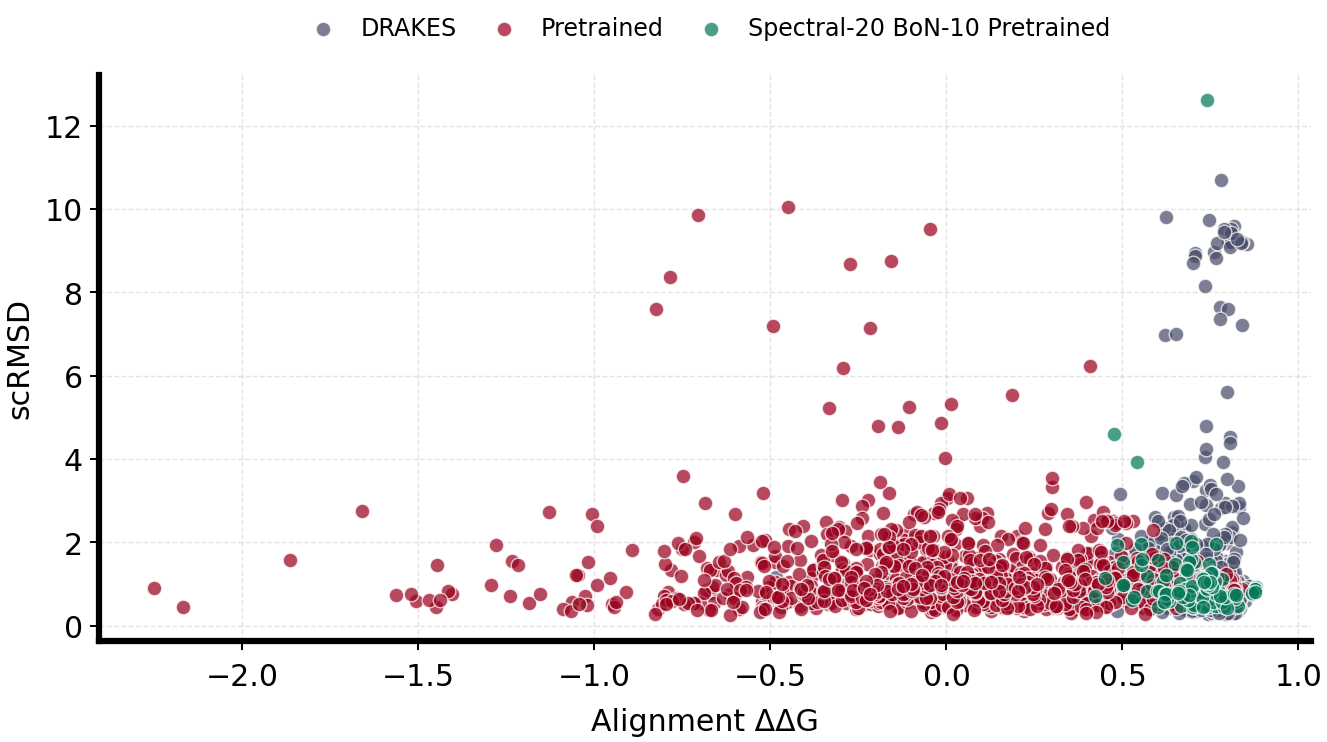

(<Figure size 1332x747 with 1 Axes>,
 <Axes: xlabel='Alignment ΔΔG', ylabel='scRMSD'>)

In [12]:
df_list = [drakes_df, pretrained_df, spec20_bon10_df]
labels = ["DRAKES", "Pretrained", "Spectral-20 BoN-10 Pretrained"]
scatter_colors = ["#4A4E69", "#9A031E", colors[1]]  # DRAKES / Pretrained match dashed baselines (legend adds dot); BoN-10 = spectral line
protein = None
title = f'{protein} ΔΔG Evaluation Oracle Distribution' if protein is not None else "ΔΔG Evaluation Oracle Distribution"

title = ''#f'{protein} ΔΔG Alignment Oracle Distribution' if protein is not None else "ΔΔG Alignment Oracle Distribution"
pdf_corr = "neurips_figures/ddg_ll_corr_mult_neurips2026.pdf"
evaluate_ddg_ll_corr_mult(
    df_list, labels, protein, title=title, selected_samples=None, colors=scatter_colors,
    ddg_label='ddg', ylabel='scrmsd', yname='scRMSD', save_pdf_path=pdf_corr,
)

Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/NeuripsProtein2026/Figures/traj_scatter_unified_neurips2026.pdf


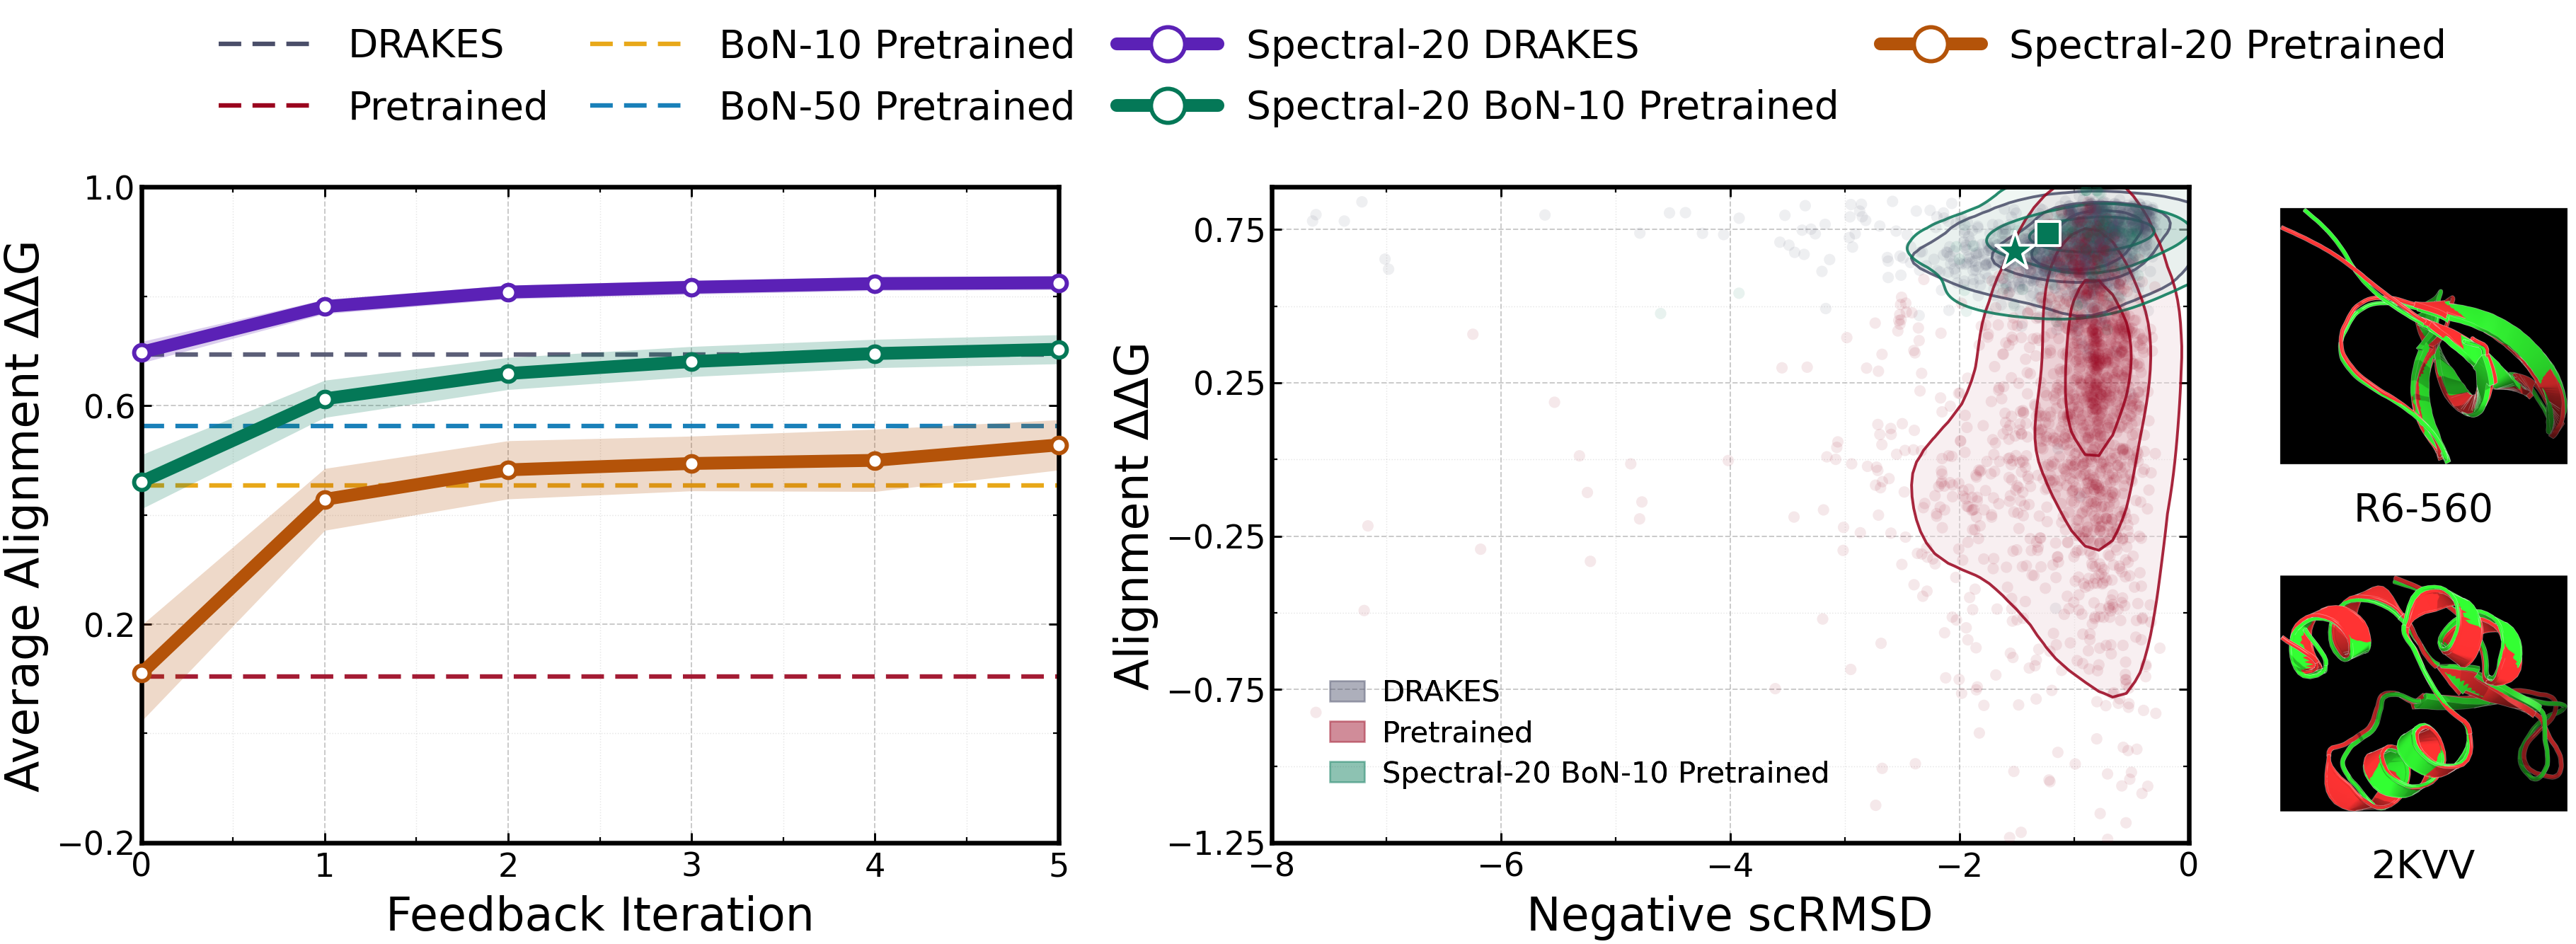

In [13]:
# Trajectory | contour-density scatter | one backbone visualization per protein.
_ = traj_and_scatter_unified_panel(
    dfs,
    names,
    colors,
    df_list,
    labels,
    scatter_colors,
    target_protein=None,
    line_title="",
    scatter_title="",
    show_baselines=True,
    show_bon=True,
    scatter_ddg_label="scrmsd",
    scatter_y="ddg",
    scatter_yname="Alignment ΔΔG",
    scatter_xname="Negative scRMSD",
    scatter_negate_x=True,
    scatter_axis_clip_quantiles=(0.01, 0.99),
    scatter_selected_samples=None,
    scatter_plot_mode="density",
    scatter_highlight_protein_specs=(
        (("r6_560_TrROS_Hall",), "*", "R6-560"),
   
        (("v2K43S_2KVV",), "s", "2KVV"),
    ),
    # Held-out ★ / □ markers only on the spectral-series contour data (matches ``df_list[2]`` order above).
    scatter_highlight_series_indices=(2,),
    scatter_outlier_protein_scatter_only=False,
    save_pdf_path=main_dir + "NeuripsProtein2026/Figures/traj_scatter_unified_neurips2026.pdf",
    err_style="band",
    # structure_image_captions=("r6_TrROS_Hall", "v2K43S_2KVV"),
    structure_image_captions=("R6-560", "2KVV"),
    structure_caption_color=colors[1],
    scatter_region_legend=True,
    # structure_crop_black_thresh=0.10,  # optional: higher = trim more dark border
    # structure_crop_edge_shrink=0.88,  # optional: lower = zoom in more after trim=0.05,
    structure_crop_padding_frac=0.02,  # optional: larger = more black margin (square frame)
    structure_crop_square=True,  # optional: disable square letterboxing
)


Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/NeuripsProtein2026/Figures/scatter_contour_only_drakes_spectral_20_rl_large.pdf


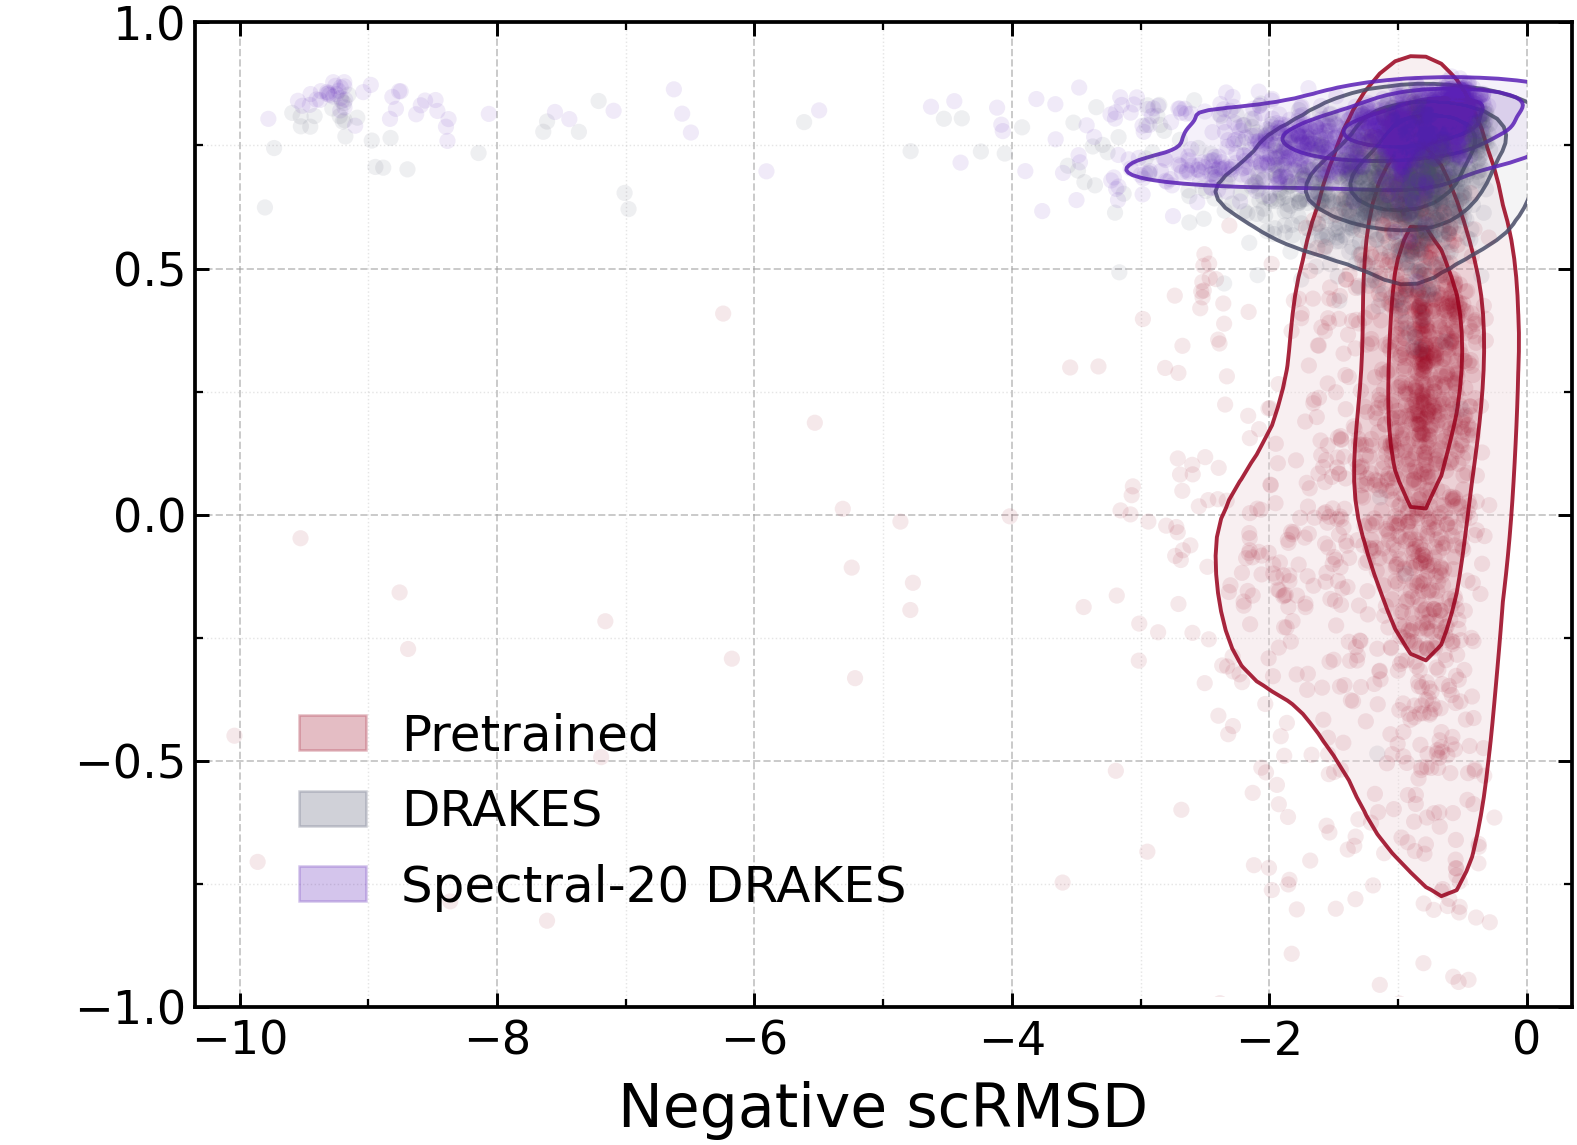

Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/NeuripsProtein2026/Figures/scatter_contour_only_pretrained_spectral_20.pdf


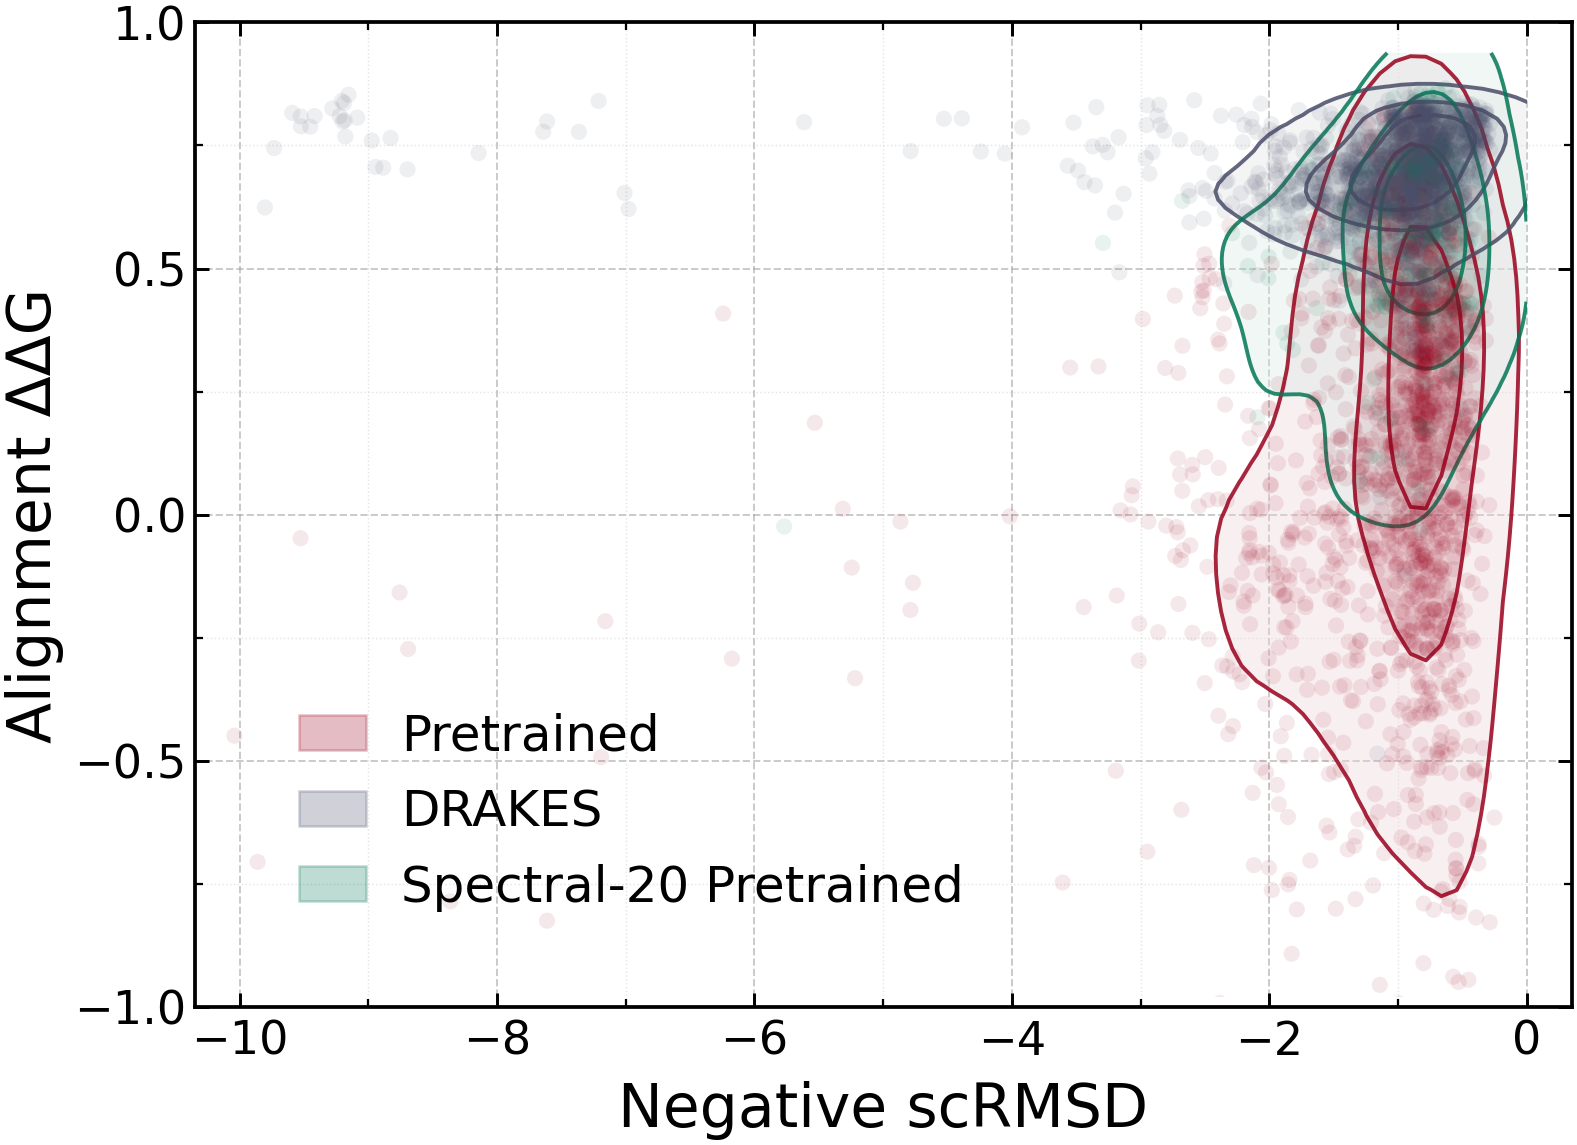

In [14]:
# Standalone contour-density scatter panel: identical content/style to the scatter slot of
# ``traj_and_scatter_unified_panel`` (faint points + held-out * / [] markers + Patch region legend),
# without the trajectory or structure-image columns.
_unified_scatter_rc = {
    "font.family": "DejaVu Sans",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Helvetica",
        "Liberation Sans",
    ],
    "mathtext.fontset": "dejavusans",
    "font.size": 16.25,
    "axes.titlesize": 19.5,
    "axes.labelsize": 24.0,
    "xtick.labelsize": 18.5,
    "ytick.labelsize": 18.5,
    "legend.fontsize": 20.0,
    "axes.edgecolor": "black",
    "axes.linewidth": 5.5,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "xtick.major.width": 1.12,
    "ytick.major.width": 1.12,
    "xtick.minor.width": 0.86,
    "ytick.minor.width": 0.86,
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.handlelength": 2.95,
    "legend.handletextpad": 0.82,
    "legend.borderpad": 0.65,
    "legend.labelspacing": 0.82,
    "legend.columnspacing": 1.38,

    # "mathtext.fontset": "dejavuserif",
    # "font.size": 16.25,
    # "axes.titlesize": 19.5,
    # "axes.labelsize": 21.0,
    # "xtick.labelsize": 16.5,
    # "ytick.labelsize": 16.5,
    # "legend.fontsize": 17.0,
    # "axes.edgecolor": "black",
    # "axes.linewidth": 5.5,
    # "axes.spines.top": True,
    # "axes.spines.right": True,
    # "axes.spines.left": True,
    # "axes.spines.bottom": True,
    # "xtick.major.width": 1.12,
    # "ytick.major.width": 1.12,
    # "xtick.minor.width": 0.86,
    # "ytick.minor.width": 0.86,
    # "xtick.color": "black",
    # "ytick.color": "black",
    # "legend.handlelength": 2.95,
    # "legend.handletextpad": 0.82,
    # "legend.borderpad": 0.65,
    # "legend.labelspacing": 0.82,
    # "legend.columnspacing": 1.38,
}

def gen_contour_plot(_df_list, _labels, _scatter_colors, fig, fn, yname="Alignment ΔΔG"):

    _set_publication_style()
    with plt.rc_context(_unified_scatter_rc):
        fig, ax_scat = plt.subplots(figsize=(9.0, 6.55))
        fig.subplots_adjust(left=0.12, right=0.97, top=0.965, bottom=0.13)

        _plot_scatter_corr_on_ax(
            ax_scat,
            _df_list,
            _labels,
            protein,
            selected_samples=None,
            colors=_scatter_colors,
            ddg_label="scrmsd",
            ylabel="ddg",
            yname=yname,
            xname="Negative scRMSD",
            negate_x=True,
            axis_clip_quantiles=(0.01, 0.99),
            scatter_marker_size=58,
            scatter_edgewidth=1.15,
            plot_mode="density",
            # No held-out ★ / □ markers on this isolated contour panel.
            highlight_protein_specs=None,
            highlight_series_indices=None,
            density_draw_highlights=False,
            outlier_protein_scatter_only=False,
            outlier_quantiles=(0.01, 0.99),
        )

        _apply_neurips_reference_axis_style(ax_scat)

        # Fixed Negative-scRMSD ticks every 2; keep natural orientation (more negative on left).
        ax_scat.set_xticks([0, -2, -4, -6, -8, -10])
        ax_scat.set_xlim(-10.35, 0.35)
        ax_scat.set_ylim(-1.0, 1.0)
        ax_scat.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])

        # Clip contours in data coords: keep axis padding past 0, but cut contours off at x=0.
        from matplotlib.patches import Rectangle
        _xl, _xr = ax_scat.get_xlim()
        _yb, _yt = ax_scat.get_ylim()
        _eps_x = 0.01 * abs(_xr - _xl)
        _eps_y = 0.01 * abs(_yt - _yb)
        _clip_x0 = _xl + _eps_x
        _clip_x1 = 0.0  # hard cutoff at 0; right padding (0 → xlim) stays empty
        _clip = Rectangle(
            (_clip_x0, _yb + _eps_y),
            max(_clip_x1 - _clip_x0, 0.0),
            max((_yt - _eps_y) - (_yb + _eps_y), 0.0),
            transform=ax_scat.transData,
            facecolor="none",
            edgecolor="none",
        )
        ax_scat.add_patch(_clip)
        _clip.set_visible(False)
        _clip.set_zorder(0)
        for coll in list(ax_scat.collections):
            coll.set_clip_on(True)
            coll.set_clip_path(_clip)
            try:
                coll.set_zorder(min(float(coll.get_zorder()), 2.0))
            except Exception:
                pass
        for line in list(ax_scat.lines):
            line.set_clip_on(True)
            line.set_clip_path(_clip)
        for spine in ax_scat.spines.values():
            spine.set_zorder(20)

        from matplotlib.patches import Patch

        region_handles = [
            Patch(
                facecolor=_scatter_colors[i % len(_scatter_colors)],
                edgecolor=_scatter_colors[i % len(_scatter_colors)],
                alpha=0.26,
                label=str(_labels[i]),
            )
            for i in range(len(_labels))
        ]
        ax_scat.legend(
            handles=region_handles,
            loc="lower left",
            bbox_to_anchor=(0.035, 0.04),
            frameon=False,
            # Use rc legend.fontsize (hardcoded fontsize= previously overrode it).
            fontsize=_unified_scatter_rc["legend.fontsize"],
            borderpad=0.62,
            handlelength=1.35,
            handletextpad=0.70,
            labelspacing=0.55,
        )

    os.makedirs(os.path.dirname(fn), exist_ok=True)
    fig.savefig(fn, format="pdf", bbox_inches="tight")
    print(f"Saved PDF to: {fn}")

    plt.show()


 #"Pretrained",  "#9A031E"

# Contour panel: keep DRAKES / Pretrained baselines; replace spectral series with large RL.
_df_list = [pretrained_df, drakes_df, spec20_rl_large_df]
_labels = ["Pretrained", "DRAKES", "Spectral-20 DRAKES"]
_scatter_colors = ["#9A031E", "#4A4E69", colors[0]]

fn = main_dir + "NeuripsProtein2026/Figures/scatter_contour_only_drakes_spectral_20_rl_large.pdf"

gen_contour_plot(_df_list, _labels, _scatter_colors, fig, fn, yname=" ")

_df_list = [pretrained_df, drakes_df, spec20_2048_fb5_df]
_labels = ["Pretrained", "DRAKES", "Spectral-20 Pretrained"]
_scatter_colors = ["#9A031E", "#4A4E69", colors[1]]

fn = main_dir + "NeuripsProtein2026/Figures/scatter_contour_only_pretrained_spectral_20.pdf"
gen_contour_plot(_df_list, _labels, _scatter_colors, fig, fn)


Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/NeuripsProtein2026/Figures/traj_blank_unified_neurips2026.pdf


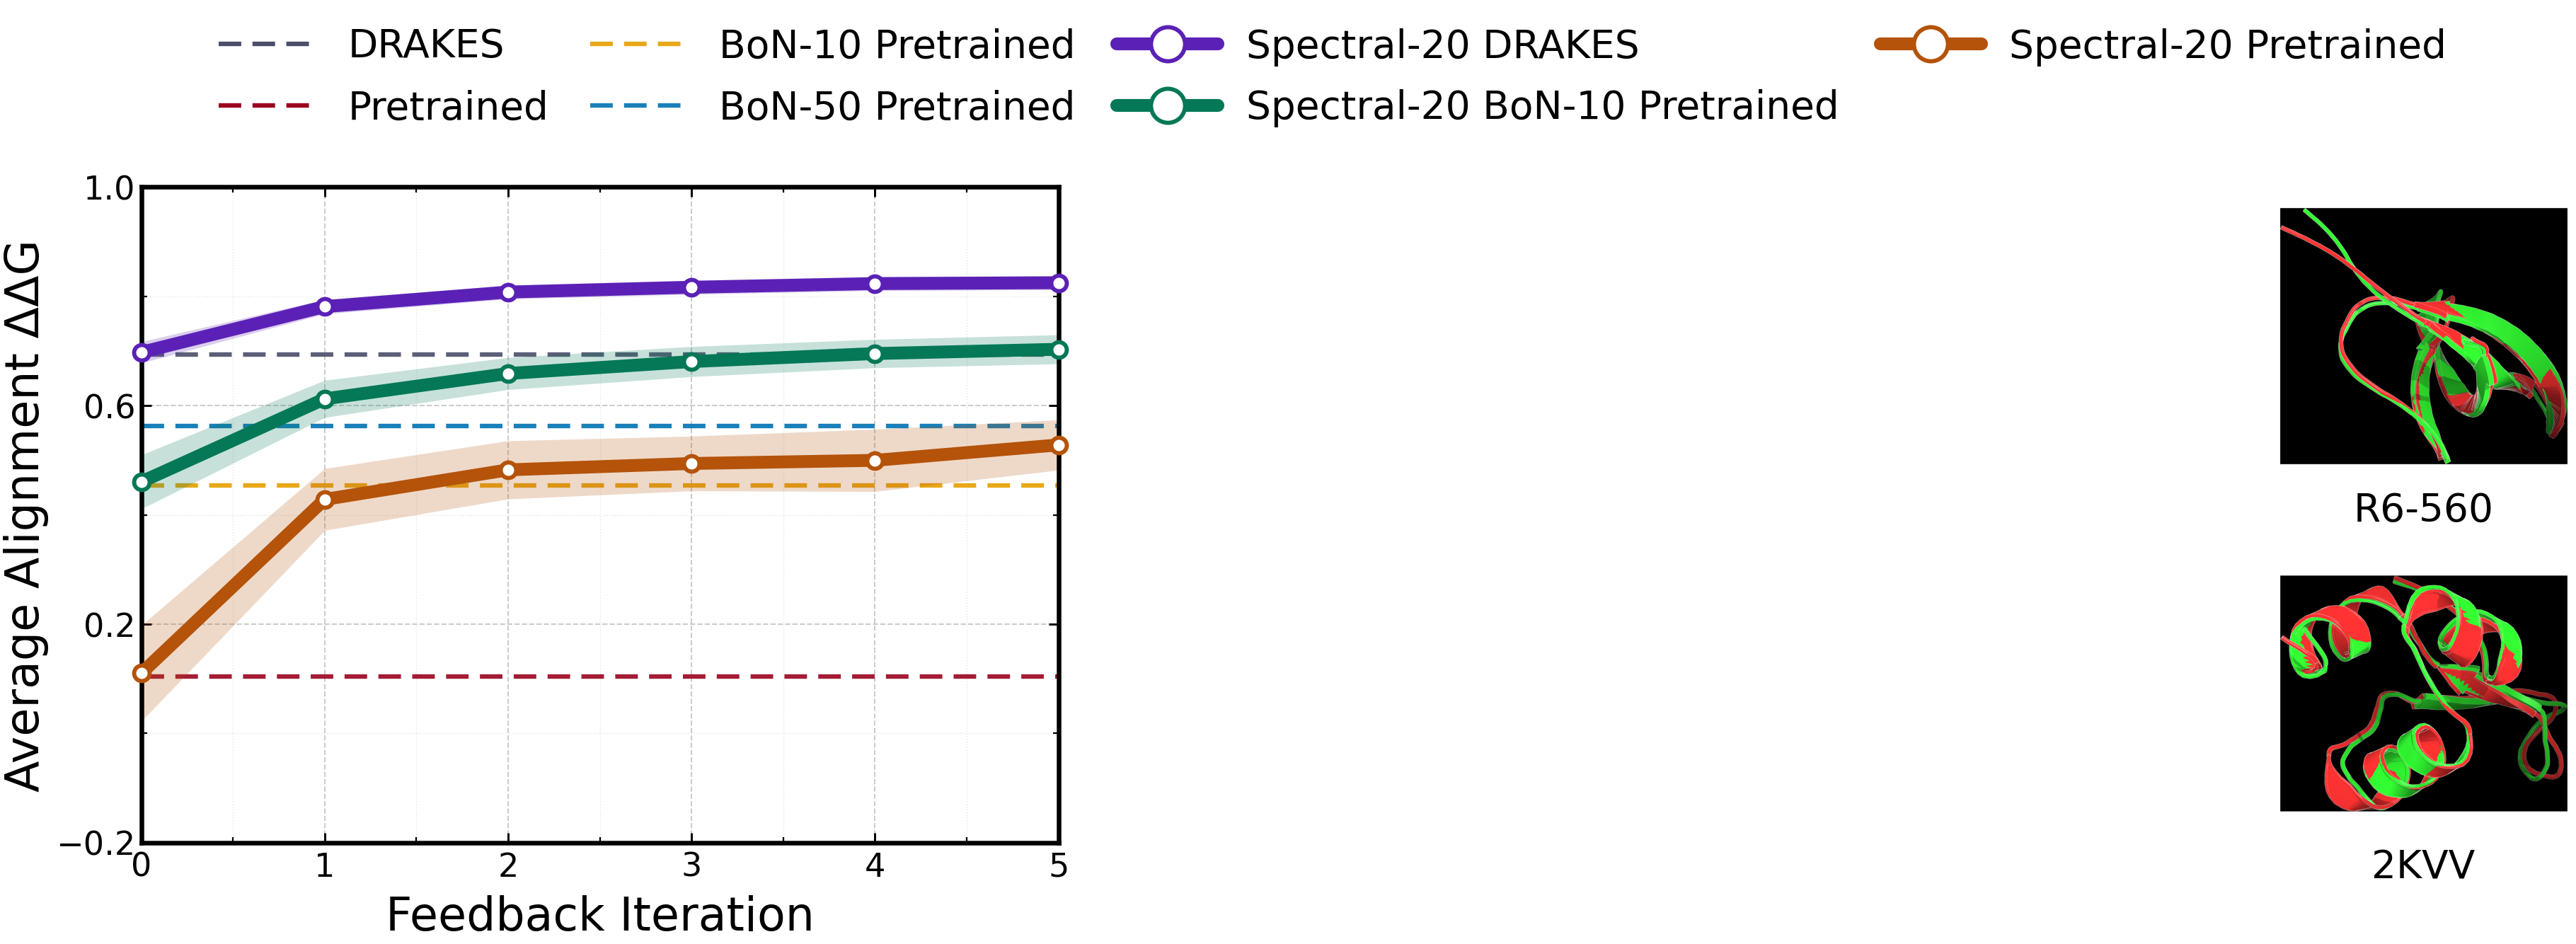

In [15]:
# Unified panel with empty middle slot (white space instead of bar/scatter).
_ = traj_and_scatter_unified_panel(
    dfs,
    names,
    colors,
    df_list,
    labels,
    scatter_colors,
    target_protein=None,
    line_title="",
    scatter_title="",
    show_baselines=True,
    show_bon=True,
    scatter_ddg_label="scrmsd",
    scatter_y="ddg",
    scatter_yname="Alignment ΔΔG",
    scatter_xname="Negative scRMSD",
    scatter_negate_x=True,
    scatter_axis_clip_quantiles=(0.01, 0.99),
    scatter_selected_samples=None,
    scatter_plot_mode="none",
    scatter_highlight_protein_specs=(
        (("r6_560_TrROS_Hall", "r6_TrROS_Hall", "r6"), "*", "R6-560"),
        (("v2K43S_2KVV",), "s", "2KVV"),
    ),
    scatter_highlight_series_indices=(2,),
    scatter_outlier_protein_scatter_only=False,
    save_pdf_path=main_dir + "NeuripsProtein2026/Figures/traj_blank_unified_neurips2026.pdf",
    err_style="band",
    structure_image_captions=("R6-560", "2KVV"),
    structure_caption_color=colors[1],
    scatter_region_legend=False,
    structure_crop_padding_frac=0.02,
    structure_crop_square=True,
)
